<a href="https://colab.research.google.com/github/ankit-verma2000/Business-Case-Delhivery/blob/main/DELHIVERY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Case: Delhivery - Feature Engineering**

**Colab link:**
https://colab.research.google.com/drive/1OnPKP2caX9C1UOP0G0AzD_9DbTQOvVJt?usp=sharing

#**About Delhivery**

Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.

# **What is expected?**
The company wants to understand and process the data coming out of data engineering pipelines:

• Clean, sanitize and manipulate data to get useful features out of raw fields

• Make sense out of the raw data and help the data science team to build forecasting models on it

## Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as spy

## Loading the Dataset and make copy

In [ ]:
data = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181')
# Copy of the above dataset
df = data.copy()
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
# Shape of the dataset(Number of rows and columns)
df.shape
print('NUMBER OF ROWS IN DATASET:',df.shape[0])
print('NUMBER OF COLUMNS IN DATASET:',df.shape[1])

NUMBER OF ROWS IN DATASET: 144867
NUMBER OF COLUMNS IN DATASET: 24


In [ ]:
# Total columns and rows in dataset:
df.size

3476808

In [ ]:
# Columns Name:
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='object')

In [ ]:
# Datatyoes of the columns:
df.dtypes

data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor                    

In [ ]:
# Basic info abut the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
# Descriptive statistics of the data:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [ ]:
# Top 5 rows of the data:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
# Laset 5 rows of the data:
df.tail()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630
144866,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 16:24:28.436231,70.039010,426.0,95.0,88.7319,4.484211,268.0,9.0,8.8088,29.777778


## Basic Analysis:

In [ ]:
# Drop the not necessary columns(or unknown fields)
unknown_fields = ['is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'factor', 'segment_factor']
df = df.drop(columns = unknown_fields)

In [ ]:
# Number of uniques entities in each column
for i in df.columns:
  print(f'Uniques entity for column "{i}" = {df[i].nunique()}')

Uniques entity for column "data" = 2
Uniques entity for column "trip_creation_time" = 14817
Uniques entity for column "route_schedule_uuid" = 1504
Uniques entity for column "route_type" = 2
Uniques entity for column "trip_uuid" = 14817
Uniques entity for column "source_center" = 1508
Uniques entity for column "source_name" = 1498
Uniques entity for column "destination_center" = 1481
Uniques entity for column "destination_name" = 1468
Uniques entity for column "od_start_time" = 26369
Uniques entity for column "od_end_time" = 26369
Uniques entity for column "start_scan_to_end_scan" = 1915
Uniques entity for column "actual_distance_to_destination" = 144515
Uniques entity for column "actual_time" = 3182
Uniques entity for column "osrm_time" = 1531
Uniques entity for column "osrm_distance" = 138046
Uniques entity for column "segment_actual_time" = 747
Uniques entity for column "segment_osrm_time" = 214
Uniques entity for column "segment_osrm_distance" = 113799


In [ ]:
# Data type conversion:(object to category)
df['data'] = df['data'].astype('category')
df['route_type'] = df['route_type'].astype('category')

##Converting time columns into pandas datetime.

In [ ]:
# Updataing the datatype of the datetime columns from object
datetime_col= ['trip_creation_time', 'od_start_time', 'od_end_time']
for i in datetime_col:
  df[i] = pd.to_datetime(df[i])

In [ ]:
# The memory usage of each column in bytes
df.memory_usage()

Index                                 128
data                               144991
trip_creation_time                1158936
route_schedule_uuid               1158936
route_type                         144991
trip_uuid                         1158936
source_center                     1158936
source_name                       1158936
destination_center                1158936
destination_name                  1158936
od_start_time                     1158936
od_end_time                       1158936
start_scan_to_end_scan            1158936
actual_distance_to_destination    1158936
actual_time                       1158936
osrm_time                         1158936
osrm_distance                     1158936
segment_actual_time               1158936
segment_osrm_time                 1158936
segment_osrm_distance             1158936
dtype: int64

In [ ]:
float_col = ['actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance',
                    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance']
for i in float_col:
    print(df[i].max())

1927.4477046975032
4532.0
1686.0
2326.1991000000003
3051.0
1611.0
2191.4037000000003


Therefore we can observe that max value in float column id less so we can convert it into float32.

In [ ]:
for i in float_col:
  df[i] = df[i].astype('float32')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  category      
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  category      
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

So memory reduction is now 15.2+ MB which was earlier 25.6+MB, making it comparetively slower.

In [ ]:
# Time Period for which the data is given:
print(f"start time : { df['od_start_time'].min()}")
print(f"End time : { df['od_end_time'].max()}")

start time : 2018-09-12 00:00:16.535741
End time : 2018-10-08 03:00:24.353479


##Handle missing values in the data.

In [ ]:
# Check for missing data in each columns:
print(f'If any null values present in the dataset : {np.any(df.isna())}')
print(f'Total Number of missing data in the dataset is : {df.isna().sum().sum()}')
df.isna().sum()

If any null values present in the dataset : True
Total Number of missing data in the dataset is : 554


data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
dtype: int64

In [ ]:
# lets find unique values in the 'source_center' column of the DataFrame 'df' for rows where the 'source_name' value is null.

In [ ]:
# We have only two columns with null values: source_name and destination_name
missing_source_name = df.loc[df['source_name'].isnull(), 'source_center'].unique()
missing_source_name

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND509103AAC', 'IND126116AAA', 'IND331022A1B',
       'IND505326AAB', 'IND852118A1B'], dtype=object)

In [ ]:
for i in missing_source_name:
    unique_source_name = df.loc[df['source_center'] == i, 'source_name'].unique()
    if pd.isna(unique_source_name):
        print("Source Center :", i, "-" * 10, "Source Name :", 'Not Found')
    else :
        print("Source Center :", i, "-" * 10, "Source Name :", unique_source_name)

Source Center : IND342902A1B ---------- Source Name : Not Found
Source Center : IND577116AAA ---------- Source Name : Not Found
Source Center : IND282002AAD ---------- Source Name : Not Found
Source Center : IND465333A1B ---------- Source Name : Not Found
Source Center : IND841301AAC ---------- Source Name : Not Found
Source Center : IND509103AAC ---------- Source Name : Not Found
Source Center : IND126116AAA ---------- Source Name : Not Found
Source Center : IND331022A1B ---------- Source Name : Not Found
Source Center : IND505326AAB ---------- Source Name : Not Found
Source Center : IND852118A1B ---------- Source Name : Not Found


In [ ]:
missing_destination_name = df.loc[df['destination_name'].isnull(), 'destination_center'].unique()
missing_destination_name

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND505326AAB', 'IND852118A1B', 'IND126116AAA',
       'IND509103AAC', 'IND221005A1A', 'IND250002AAC', 'IND331001A1C',
       'IND122015AAC'], dtype=object)

In [ ]:
for i in missing_destination_name:
    unique_destination_name = df.loc[df['destination_center'] == i, 'destination_name'].unique()
    if (pd.isna(unique_destination_name)) or (unique_destination_name.size == 0):
        print("Destination Center :", i, "-" * 10, "Destination Name :", 'Not Found')
    else :
        print("Destination Center :", i, "-" * 10, "Destination Name :", unique_destination_name)

Destination Center : IND342902A1B ---------- Destination Name : Not Found
Destination Center : IND577116AAA ---------- Destination Name : Not Found
Destination Center : IND282002AAD ---------- Destination Name : Not Found
Destination Center : IND465333A1B ---------- Destination Name : Not Found
Destination Center : IND841301AAC ---------- Destination Name : Not Found
Destination Center : IND505326AAB ---------- Destination Name : Not Found
Destination Center : IND852118A1B ---------- Destination Name : Not Found
Destination Center : IND126116AAA ---------- Destination Name : Not Found
Destination Center : IND509103AAC ---------- Destination Name : Not Found
Destination Center : IND221005A1A ---------- Destination Name : Not Found
Destination Center : IND250002AAC ---------- Destination Name : Not Found
Destination Center : IND331001A1C ---------- Destination Name : Not Found
Destination Center : IND122015AAC ---------- Destination Name : Not Found


In [ ]:
# Rows where 'source_name' is null
rows_with_null_source_name = df['source_name'].isnull()

# Get 'source_center' values from these rows
source_centers_with_null_source_name = df.loc[rows_with_null_source_name, 'source_center']

# Check if each of these 'source_center' values is in 'missing_destination_name'
all_values_in_missing_destination_name = np.all(source_centers_with_null_source_name.isin(missing_destination_name))

all_values_in_missing_destination_name

False

##Treating missing 'destination names' and 'source names'

In [ ]:
# Initialize a counter for unique placeholder names
count = 1

# Impute missing 'destination_name' values
for i in missing_destination_name:
    placeholder_name = f'location_{count}'
    df.loc[df['destination_center'] == i, 'destination_name'] = df.loc[df['destination_center'] == i, 'destination_name'].replace(np.nan, placeholder_name)
    count += 1

# Create and apply a mapping for 'source_center' to 'destination_name'
d = {}
for i in missing_source_name:
    unique_names = df.loc[df['destination_center'] == i, 'destination_name'].unique()
    d[i] = unique_names if len(unique_names) > 0 else [f'location_{count}']
    count += (len(unique_names) == 0)

# Simplify the mapping to use only the first 'destination_name' or the assigned placeholder
d2 = {idx: val[0] for idx, val in d.items()}

# Apply the mapping to fill missing 'source_name' values
for i, v in d2.items():
    df.loc[df['source_center'] == i, 'source_name'] = df.loc[df['source_center'] == i, 'source_name'].replace(np.nan, v)

In [ ]:
df.isna().sum()

data                              0
trip_creation_time                0
route_schedule_uuid               0
route_type                        0
trip_uuid                         0
source_center                     0
source_name                       0
destination_center                0
destination_name                  0
od_start_time                     0
od_end_time                       0
start_scan_to_end_scan            0
actual_distance_to_destination    0
actual_time                       0
osrm_time                         0
osrm_distance                     0
segment_actual_time               0
segment_osrm_time                 0
segment_osrm_distance             0
dtype: int64

In [ ]:
df.describe(include = 'object')

,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name
count,144867,144867,144867,144867,144867,144867
unique,1504,14817,1508,1508,1481,1481
top,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,trip-153811219535896559,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana)
freq,1812,101,23347,23347,15192,15192


##**Merging the rows**







---



1. Grouping by segment

a. Create a unique identifier for different segments of a trip based on the
combination of the trip_uuid, source_center, and destination_center and
name it as segment_key.

In [ ]:
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'actual_distance_to_destination',
       'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance'],
      dtype='object')

In [ ]:
# Creating a unique identifier for each segment of a trip
df['segment_key'] = df['trip_uuid'] + '_' + df['source_center'] + '_' + df['destination_center']

# Using cumsum() to merge the rows for specified columns based on segment_key
cumulative_columns = {
    'segment_actual_time': 'segment_actual_time_sum',
    'segment_osrm_distance': 'segment_osrm_distance_sum',
    'segment_osrm_time': 'segment_osrm_time_sum'
}

for original_col, new_col in cumulative_columns.items():
    df[new_col] = df.groupby('segment_key')[original_col].cumsum()

df[['segment_key', 'segment_actual_time', 'segment_actual_time_sum',
      'segment_osrm_distance', 'segment_osrm_distance_sum',
      'segment_osrm_time', 'segment_osrm_time_sum']]

,segment_key,segment_actual_time,segment_actual_time_sum,segment_osrm_distance,segment_osrm_distance_sum,segment_osrm_time,segment_osrm_time_sum
0,trip-153741093647649320_IND388121AAA_IND388620AAB,14.0,14.0,11.965300,11.965300,11.0,11.0
1,trip-153741093647649320_IND388121AAA_IND388620AAB,10.0,24.0,9.759000,21.724300,9.0,20.0
2,trip-153741093647649320_IND388121AAA_IND388620AAB,16.0,40.0,10.815200,32.539497,7.0,27.0
3,trip-153741093647649320_IND388121AAA_IND388620AAB,21.0,61.0,13.022400,45.561897,12.0,39.0
4,trip-153741093647649320_IND388121AAA_IND388620AAB,6.0,67.0,3.915300,49.477200,5.0,44.0
...,...,...,...,...,...,...,...
144862,trip-153746066843555182_IND131028AAB_IND000000ACB,12.0,92.0,8.185800,65.348701,12.0,94.0
144863,trip-153746066843555182_IND131028AAB_IND000000ACB,26.0,118.0,17.372499,82.721199,21.0,115.0
144864,trip-153746066843555182_IND131028AAB_IND000000ACB,20.0,138.0,20.705299,103.426498,34.0,149.0
144865,trip-153746066843555182_IND131028AAB_IND000000ACB,17.0,155.0,18.888500,122.315002,27.0,176.0


In [ ]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_key,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,14.0,11.0,11.965300,14.0,11.0,11.9653,trip-153741093647649320_IND388121AAA_IND388620AAB,14.0,11.965300,11.0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,24.0,20.0,21.724300,10.0,9.0,9.7590,trip-153741093647649320_IND388121AAA_IND388620AAB,24.0,21.724300,20.0
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,40.0,28.0,32.539501,16.0,7.0,10.8152,trip-153741093647649320_IND388121AAA_IND388620AAB,40.0,32.539497,27.0
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,62.0,40.0,45.562000,21.0,12.0,13.0224,trip-153741093647649320_IND388121AAA_IND388620AAB,61.0,45.561897,39.0
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,68.0,44.0,54.218102,6.0,5.0,3.9153,trip-153741093647649320_IND388121AAA_IND388620AAB,67.0,49.477200,44.0


In [ ]:
# Aggregating at segment level

# Creating a dictionary for aggregation at segment level
create_segment_dict = {
  'trip_uuid' : 'first',
  'data': 'first',
  'route_type': 'first',
  'trip_creation_time': 'first',
  'source_name': 'first',
  'destination_name': 'last',
  'od_start_time': 'first',
  'od_end_time': 'last',
  'start_scan_to_end_scan': 'first',
  'actual_distance_to_destination': 'last',
  'actual_time': 'last',
  'osrm_time': 'last',
  'osrm_distance': 'last',
  'segment_actual_time' : 'sum',
  'segment_osrm_time' : 'sum',
  'segment_osrm_distance' : 'sum',
  'segment_actual_time_sum': 'last',
  'segment_osrm_time_sum': 'last',
  'segment_osrm_distance_sum': 'last',
}

# Grouping by segment_key and applying the aggregation operations
seg_agg_data = df.groupby('segment_key').agg(create_segment_dict).reset_index()

# Sorting in ascending order
seg_agg_data = seg_agg_data.sort_values(by=['segment_key','od_end_time'])

seg_agg_data

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,trip-153671041653548748_IND209304AAA_IND000000ACB,trip-153671041653548748,training,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,1260.0,383.759155,732.0,329.0,446.549591,728.0,534.0,670.620483,728.0,534.0,670.620483
1,trip-153671041653548748_IND462022AAA_IND209304AAA,trip-153671041653548748,training,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,999.0,440.973694,830.0,388.0,544.802673,820.0,474.0,649.852783,820.0,474.0,649.852783
2,trip-153671042288605164_IND561203AAB_IND562101AAA,trip-153671042288605164,training,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,58.0,24.644020,47.0,26.0,28.199400,46.0,26.0,28.199501,46.0,26.0,28.199501
3,trip-153671042288605164_IND572101AAA_IND561203AAB,trip-153671042288605164,training,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,122.0,48.542889,96.0,42.0,56.911598,95.0,39.0,55.989899,95.0,39.0,55.989899
4,trip-153671043369099517_IND000000ACB_IND160002AAC,trip-153671043369099517,training,FTL,2018-09-12 00:00:33.691250,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,834.0,237.439606,611.0,212.0,281.210907,608.0,231.0,317.740784,608.0,231.0,317.740784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26363,trip-153861115439069069_IND628204AAA_IND627657AAA,trip-153861115439069069,test,Carting,2018-10-03 23:59:14.390954,Tirchchndr_Shnmgprm_D (Tamil Nadu),Thisayanvilai_UdnkdiRD_D (Tamil Nadu),2018-10-04 02:29:04.272194,2018-10-04 03:31:11.183797,62.0,33.627182,51.0,41.0,42.521301,49.0,42.0,42.143101,49.0,42.0,42.143101
26364,trip-153861115439069069_IND628613AAA_IND627005AAA,trip-153861115439069069,test,Carting,2018-10-03 23:59:14.390954,Peikulam_SriVnktpm_D (Tamil Nadu),Tirunelveli_VdkkuSrt_I (Tamil Nadu),2018-10-04 04:16:39.894872,2018-10-04 05:47:45.162682,91.0,33.673836,90.0,48.0,40.608002,89.0,77.0,78.586899,89.0,77.0,78.586899
26365,trip-153861115439069069_IND628801AAA_IND628204AAA,trip-153861115439069069,test,Carting,2018-10-03 23:59:14.390954,Eral_Busstand_D (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),2018-10-04 01:44:53.808000,2018-10-04 02:29:04.272194,44.0,12.661944,30.0,14.0,16.018499,29.0,14.0,16.018400,29.0,14.0,16.018400
26366,trip-153861118270144424_IND583119AAA_IND583101AAA,trip-153861118270144424,test,FTL,2018-10-03 23:59:42.701692,Sandur_WrdN1DPP_D (Karnataka),Bellary_Dc (Karnataka),2018-10-04 03:58:40.726547,2018-10-04 08:46:09.166940,287.0,40.546738,233.0,42.0,52.530300,233.0,42.0,52.530300,233.0,42.0,52.530300


The rows have been merged based on the unique segment_key, which is a combination of trip_uuid, source_center, and destination_center. The aggregated dataset reflects the total values for each segment of the trip. How the aggregation was performed:

**Numerical Fields:**
*  The Feilds segment_actual_time, segment_osrm_time, segment_osrm_distance were summed up.
*  This gives a total measure of time and distance for each unique segment.

**Categorical/Boolean Fields:**
* For fields like route_type, the first value in each group was kept.
* The data field, which distinguishes between training and testing data, was also preserved with the first value.

**Source and Destination Names:**
* The source_name field retains the first source name for each segment.
* The destination_name field holds the last destination name for each segment.

##Feature Engineering:

1. Calculate time taken between od_start_time and od_end_time and keep it as a
feature named od_time_diff_hour. Drop the original columns, if required.

In [ ]:
# Time difference between od_start_time and od_end_time
seg_agg_data['od_total_time'] = (
    seg_agg_data['od_end_time'] - seg_agg_data['od_start_time']
).dt.total_seconds() / 60

**Creating new feature**

In [ ]:
# Performing aggregation on the groupby trip uuid and name it as fe(feature_engineering)

# All the aggregate that we will perform on the different columns
create_trip_dict={
  'data' : 'first',
  'route_type' : 'first',
  'od_total_time' : 'sum',
  'trip_creation_time' : 'first',
  'start_scan_to_end_scan' : 'sum',
  'source_name': 'first',
  'destination_name': 'last',
  'actual_distance_to_destination' : 'sum',
  'actual_time' : 'sum',
  'osrm_time' : 'sum',
  'osrm_distance' : 'sum',
  'segment_actual_time': 'sum',
  'segment_osrm_time': 'sum',
  'segment_osrm_distance': 'sum',
  'segment_actual_time_sum': 'sum',
  'segment_osrm_time_sum': 'sum',
  'segment_osrm_distance_sum': 'sum',
  }

# Aggregation on diff col
df1 = seg_agg_data.groupby('trip_uuid').agg(create_trip_dict).reset_index()
df1

,trip_uuid,data,route_type,od_total_time,trip_creation_time,start_scan_to_end_scan,source_name,destination_name,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,trip-153671041653548748,training,FTL,2260.109800,2018-09-12 00:00:16.535741,2259.0,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),824.732849,1562.0,717.0,991.352295,1548.0,1008.0,1320.473267,1548.0,1008.0,1320.473267
1,trip-153671042288605164,training,Carting,181.611874,2018-09-12 00:00:22.886430,180.0,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),73.186905,143.0,68.0,85.111000,141.0,65.0,84.189400,141.0,65.0,84.189400
2,trip-153671043369099517,training,FTL,3934.362520,2018-09-12 00:00:33.691250,3933.0,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),1927.404297,3347.0,1740.0,2354.066650,3308.0,1941.0,2545.267822,3308.0,1941.0,2545.267822
3,trip-153671046011330457,training,Carting,100.494935,2018-09-12 00:01:00.113710,100.0,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),17.175274,59.0,15.0,19.680000,59.0,16.0,19.876600,59.0,16.0,19.876600
4,trip-153671052974046625,training,FTL,718.349042,2018-09-12 00:02:09.740725,717.0,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),127.448502,341.0,117.0,146.791794,340.0,115.0,146.791901,340.0,115.0,146.791901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14812,trip-153861095625827784,test,Carting,258.028928,2018-10-03 23:55:56.258533,257.0,Chandigarh_Mehmdpur_H (Punjab),Chandigarh_Mehmdpur_H (Punjab),57.762333,83.0,62.0,73.462997,82.0,62.0,64.855103,82.0,62.0,64.855103
14813,trip-153861104386292051,test,Carting,60.590521,2018-10-03 23:57:23.863155,60.0,FBD_Balabhgarh_DPC (Haryana),Faridabad_Blbgarh_DC (Haryana),15.513784,21.0,12.0,16.088200,21.0,11.0,16.088299,21.0,11.0,16.088299
14814,trip-153861106442901555,test,Carting,422.119867,2018-10-03 23:57:44.429324,421.0,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),38.684837,282.0,48.0,58.903702,281.0,88.0,104.886597,281.0,88.0,104.886597
14815,trip-153861115439069069,test,Carting,348.512862,2018-10-03 23:59:14.390954,347.0,Tirunelveli_VdkkuSrt_I (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),134.723831,264.0,179.0,171.110306,258.0,221.0,223.532394,258.0,221.0,223.532394


##Build some features to prepare the data for actual analysis. Extract features from the below fields:

1. Destination Name: Split and extract features out of destination. City-place-code (State)
2. Source Name: Split and extract features out of destination. City-place-code (State)
3. Trip_creation_time: Extract features like month, year and day etc

In [ ]:
def location_name_to_state(x):
    l = x.split('(')
    if len(l) == 1:
        return l[0]
    else:
        return l[1].replace(')', "")

def location_name_to_city(x):
    if 'location' in x:
        return 'unknown_city'
    else:
        l = x.split()[0].split('_')
        if 'CCU' in x:
            return 'Kolkata'
        elif 'MAA' in x.upper():
            return 'Chennai'
        elif ('HBR' in x.upper()) or ('BLR' in x.upper()):
            return 'Bengaluru'
        elif 'FBD' in x.upper():
            return 'Faridabad'
        elif 'BOM' in x.upper():
            return 'Mumbai'
        elif 'DEL' in x.upper():
            return 'Delhi'
        elif 'OK' in x.upper():
            return 'Delhi'
        elif 'GZB' in x.upper():
            return 'Ghaziabad'
        elif 'GGN' in x.upper():
            return 'Gurgaon'
        elif 'AMD' in x.upper():
            return 'Ahmedabad'
        elif 'CJB' in x.upper():
            return 'Coimbatore'
        elif 'HYD' in x.upper():
            return 'Hyderabad'
        return l[0]

def location_name_to_place(x):
    if 'location' in x:
        return x
    elif 'HBR' in x:
        return 'HBR Layout PC'
    else:
        l = x.split()[0].split('_', 1)
        if len(l) == 1:
            return 'unknown_place'
        else:
            return l[1]

In [ ]:
# Extract state city place code from source name:

df1['source_state'] = df1['source_name'].apply(location_name_to_state)
df1['source_city'] = df1['source_name'].apply(location_name_to_city)
df1['source_place'] = df1['source_name'].apply(location_name_to_place)

In [ ]:
# Extract state city place code from destination name:

df1['destination_state'] = df1['destination_name'].apply(location_name_to_state)
df1['destination_city'] = df1['destination_name'].apply(location_name_to_city)
df1['destination_place'] = df1['destination_name'].apply(location_name_to_place)

In [ ]:
df1.head(2)
print(df.shape)

(144867, 23)


In [ ]:
# Droping the source name and destination name columns from df1 (dataframe):
df1.drop(['source_name','destination_name'],axis = 1,inplace = True)

In [ ]:
df1.head(2)

,trip_uuid,data,route_type,od_total_time,trip_creation_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,...,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_state,source_city,source_place,destination_state,destination_city,destination_place
0,trip-153671041653548748,training,FTL,2260.109800,2018-09-12 00:00:16.535741,2259.0,824.732849,1562.0,717.0,991.352295,...,1320.473267,1548.0,1008.0,1320.473267,Uttar Pradesh,Kanpur,Central_H_6,Uttar Pradesh,Kanpur,Central_H_6
1,trip-153671042288605164,training,Carting,181.611874,2018-09-12 00:00:22.886430,180.0,73.186905,143.0,68.0,85.111000,...,84.189400,141.0,65.0,84.189400,Karnataka,Doddablpur,ChikaDPP_D,Karnataka,Doddablpur,ChikaDPP_D


**Trip_creation_time:** Extract features like month, year and day etc:

As out column trip creation time is already in datatime datatype then we can easily extration out the month year day..etc fields from it.

In [ ]:
df1['trip_creation_month'] = df1['trip_creation_time'].dt.month
df1['trip_creation_month'] = df1['trip_creation_month'].astype('int8')
df1['trip_creation_year'] = df1['trip_creation_time'].dt.year
df1['trip_creation_year'] = df1['trip_creation_year'].astype('int16')
df1['trip_creation_day'] = df1['trip_creation_time'].dt.day
df1['trip_creation_day'] = df1['trip_creation_day'].astype('int8')
df1['trip_creation_hour'] = df1['trip_creation_time'].dt.hour
df1['trip_creation_hour'] = df1['trip_creation_hour'].astype('int8')
df1['trip_creation_week'] = df1['trip_creation_time'].dt.isocalendar().week
df1['trip_creation_week'] = df1['trip_creation_week'].astype('int8')
df1['trip_creation_weekday'] = df1['trip_creation_time'].dt.day_of_week
df1['trip_creation_weekday'] = df1['trip_creation_weekday'].astype('int8')

**Now lets see the dataset basic info:**


In [ ]:
df1.head()

,trip_uuid,data,route_type,od_total_time,trip_creation_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,...,source_place,destination_state,destination_city,destination_place,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_week,trip_creation_weekday
0,trip-153671041653548748,training,FTL,2260.109800,2018-09-12 00:00:16.535741,2259.0,824.732849,1562.0,717.0,991.352295,...,Central_H_6,Uttar Pradesh,Kanpur,Central_H_6,9,2018,12,0,37,2
1,trip-153671042288605164,training,Carting,181.611874,2018-09-12 00:00:22.886430,180.0,73.186905,143.0,68.0,85.111000,...,ChikaDPP_D,Karnataka,Doddablpur,ChikaDPP_D,9,2018,12,0,37,2
2,trip-153671043369099517,training,FTL,3934.362520,2018-09-12 00:00:33.691250,3933.0,1927.404297,3347.0,1740.0,2354.066650,...,Bilaspur_HB,Haryana,Gurgaon,Bilaspur_HB,9,2018,12,0,37,2
3,trip-153671046011330457,training,Carting,100.494935,2018-09-12 00:01:00.113710,100.0,17.175274,59.0,15.0,19.680000,...,unknown_place,Maharashtra,Mumbai,MiraRd_IP,9,2018,12,0,37,2
4,trip-153671052974046625,training,FTL,718.349042,2018-09-12 00:02:09.740725,717.0,127.448502,341.0,117.0,146.791794,...,Dc,Karnataka,Sandur,WrdN1DPP_D,9,2018,12,0,37,2


In [ ]:
df1.shape

(14817, 28)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14817 entries, 0 to 14816
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   trip_uuid                       14817 non-null  object        
 1   data                            14817 non-null  category      
 2   route_type                      14817 non-null  category      
 3   od_total_time                   14817 non-null  float64       
 4   trip_creation_time              14817 non-null  datetime64[ns]
 5   start_scan_to_end_scan          14817 non-null  float64       
 6   actual_distance_to_destination  14817 non-null  float32       
 7   actual_time                     14817 non-null  float32       
 8   osrm_time                       14817 non-null  float32       
 9   osrm_distance                   14817 non-null  float32       
 10  segment_actual_time             14817 non-null  float32       
 11  se

In [ ]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
od_total_time,14817.0,531.795209,659.184525,23.461468,149.930591,280.765626,638.199071,7898.551955
start_scan_to_end_scan,14817.0,530.810016,658.705957,23.000000,149.000000,280.000000,637.000000,7898.000000
actual_distance_to_destination,14817.0,164.477829,305.388153,9.002461,22.837238,48.474072,164.583206,2186.531738
actual_time,14817.0,357.143768,561.396118,9.000000,67.000000,149.000000,370.000000,6265.000000
osrm_time,14817.0,161.384018,271.360992,6.000000,29.000000,60.000000,168.000000,2032.000000
osrm_distance,14817.0,204.344711,370.395569,9.072900,30.819201,65.618805,208.475006,2840.081055
segment_actual_time,14817.0,353.892273,556.247925,9.000000,66.000000,147.000000,367.000000,6230.000000
segment_osrm_time,14817.0,180.949783,314.542053,6.000000,31.000000,65.000000,185.000000,2564.000000
segment_osrm_distance,14817.0,223.201157,416.628387,9.072900,32.654499,70.154404,218.802399,3523.632324
segment_actual_time_sum,14817.0,353.892273,556.247925,9.000000,66.000000,147.000000,367.000000,6230.000000


In [ ]:
df1.describe(include = 'object').T

,count,unique,top,freq
trip_uuid,14817,14817,trip-153671041653548748,1
source_state,14817,34,Maharashtra,2714
source_city,14817,690,Mumbai,1442
source_place,14817,761,Bilaspur_HB,1063
destination_state,14817,39,Maharashtra,2561
destination_city,14817,806,Mumbai,1548
destination_place,14817,850,Bilaspur_HB,821


# **In-depth analysis:**

In [ ]:
df1.columns

Index(['trip_uuid', 'data', 'route_type', 'od_total_time',
       'trip_creation_time', 'start_scan_to_end_scan',
       'actual_distance_to_destination', 'actual_time', 'osrm_time',
       'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
       'segment_osrm_distance', 'segment_actual_time_sum',
       'segment_osrm_time_sum', 'segment_osrm_distance_sum', 'source_state',
       'source_city', 'source_place', 'destination_state', 'destination_city',
       'destination_place', 'trip_creation_month', 'trip_creation_year',
       'trip_creation_day', 'trip_creation_hour', 'trip_creation_week',
       'trip_creation_weekday'],
      dtype='object')

In [ ]:
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')

In [ ]:
# Distribution of the orders by route type
df_route = df1.groupby('route_type')['trip_uuid'].agg('count').to_frame().reset_index()
df_route['Pct'] = round(df_route['trip_uuid']*100/ df_route['trip_uuid'].sum(),2)
df_route

,route_type,trip_uuid,Pct
0,Carting,8908,60.12
1,FTL,5909,39.88


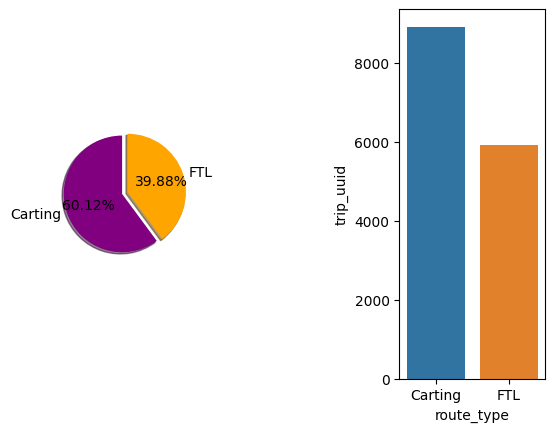

In [ ]:
# Pie chart
plt.subplot(1, 3, 1)  # Create a subplot for the pie chart
plt.pie(x = df_route['trip_uuid'],colors = ['purple','orange'] ,explode = [0,0.1],autopct = '%.2f%%',labels = ['Carting','FTL'],shadow=True, startangle=90)

# Bar chart
plt.subplot(1, 3, 3)  # Create a subplot for the bar chart
sns.barplot(data = df_route , x= df_route['route_type'], y = df_route['trip_uuid'])

plt.show()

In [ ]:
# Distribution of the data by orders:
df_data = df1.groupby('data')['trip_uuid'].agg('count').to_frame().reset_index()
df_data['pct'] = round((df_data['trip_uuid'] * 100)/df_data['trip_uuid'].sum(),2)
df_data

,data,trip_uuid,pct
0,test,4163,28.1
1,training,10654,71.9


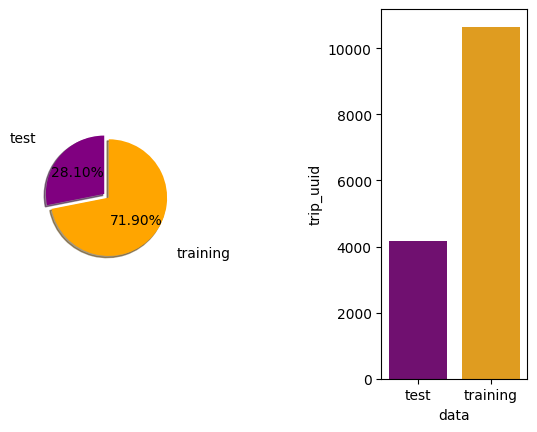

In [ ]:
# Pie chart
plt.subplot(1, 3, 1)  # Create a subplot for the pie chart
plt.pie(x=df_data['trip_uuid'], colors=['purple', 'orange'], explode=[0, 0.1], autopct='%.2f%%', labels=df_data['data'], shadow=True,labeldistance= 1.5 , startangle = 90)

# Bar chart
plt.subplot(1, 3, 3)  # Create a subplot for the bar chart
sns.barplot(data = df_data, x=df_data['data'],y= df_data['trip_uuid'], palette=['purple', 'orange'])

plt.show()

In [ ]:
# How many trips are created on the hourly basis?
df_hour = df1.groupby('trip_creation_hour')['trip_uuid'].agg('count').to_frame().reset_index()
df_hour.rename(columns = {'trip_uuid':'trip_count'},inplace =True)
df_hour.head()

,trip_creation_hour,trip_count
0,0,994
1,1,750
2,2,702
3,3,652
4,4,636


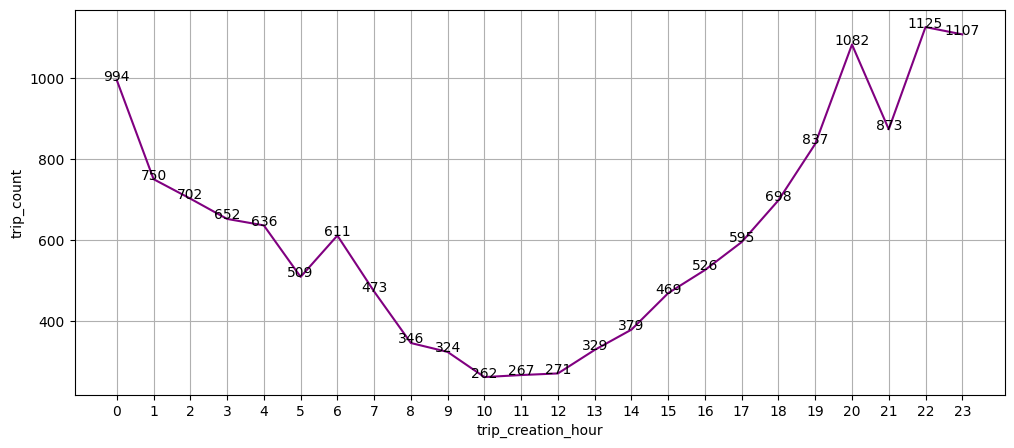

In [ ]:
plt.figure(figsize = (12,5))
sns.lineplot(data = df_hour,x = df_hour['trip_creation_hour'],y = df_hour['trip_count'],color="purple")
plt.xticks(np.arange(0,24))
addlabels(df_hour['trip_creation_hour'],df_hour['trip_count'])
plt.grid()
plt.show()

* It can be inferred from the above plot that the number of trips start increasing at afternoon drastically.
* Peak hour is at 10 P.M and then start decreasing.
* And not peek hour is at 5 Am in early morning.

In [ ]:
# How many trips are created for different days of the month?
df_day = df1.groupby('trip_creation_day')['trip_uuid'].agg('count').to_frame().reset_index()
df_day.rename(columns= {'trip_uuid':'trip_count'},inplace=True)
df_day.head()

,trip_creation_day,trip_count
0,1,605
1,2,552
2,3,631
3,12,747
4,13,750


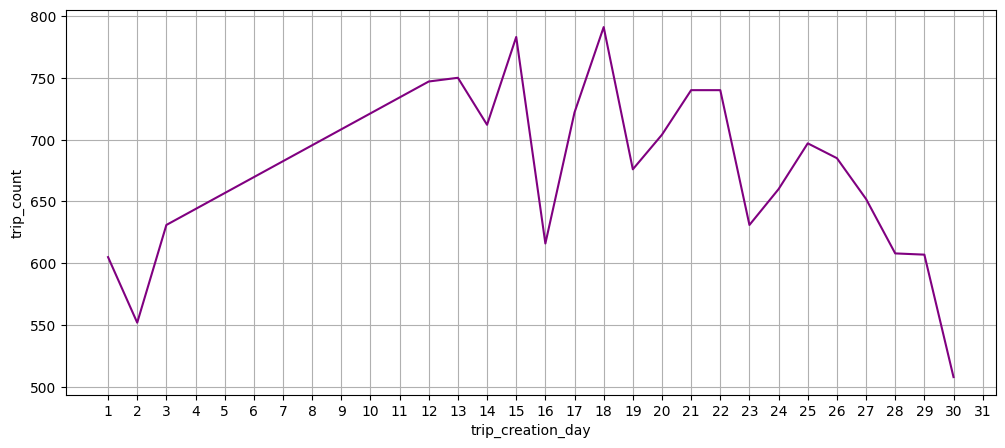

In [ ]:
plt.figure(figsize = (12,5))
sns.lineplot(data = df_day, x = df_day['trip_creation_day'],y = df_day['trip_count'],color='purple')
plt.xticks(np.arange(1,32))
plt.grid()
plt.show()

* We can infer that customer make orders usually in the mid of the month most of month.
* And less number of order in the stat and end of the month.

In [ ]:
# how many trips were created in which day?
df_week_day = df1.groupby('trip_creation_weekday')['trip_uuid'].agg('count').to_frame().reset_index()
df_week_day.rename(columns = {'trip_uuid':'trip_count'},inplace = True)
df_week_day

,trip_creation_weekday,trip_count
0,0,1987
1,1,2040
2,2,2739
3,3,2106
4,4,2060
5,5,2130
6,6,1755


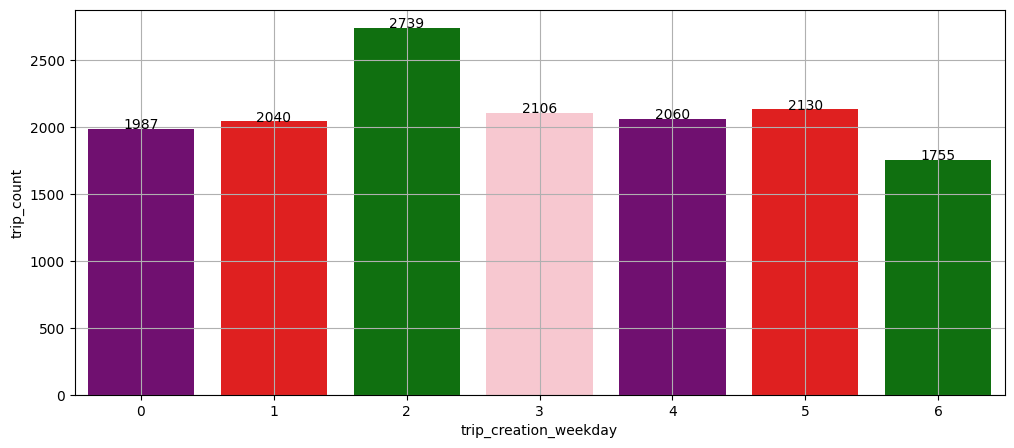

In [ ]:
plt.figure(figsize = (12,5))
sns.barplot(data=df_week_day, x=df_week_day['trip_creation_weekday'], y=df_week_day['trip_count'], palette=['purple', 'red', 'green', 'pink'])
addlabels(df_week_day['trip_creation_weekday'], df_week_day['trip_count'])
plt.grid()
plt.show()

Tuesday is the day with the highest trip creation time. This could be because that there is a day gap given post the weekend when people would make the most purchases so as to consolidate the orders and reduce trips.

In [ ]:
# How many trips were created in the week?
df_week = df1.groupby('trip_creation_week')['trip_uuid'].agg('count').to_frame().reset_index()
df_week.rename(columns = {'trip_uuid':'trip_count'},inplace=True)
df_week.head()

,trip_creation_week,trip_count
0,37,3608
1,38,5004
2,39,4417
3,40,1788


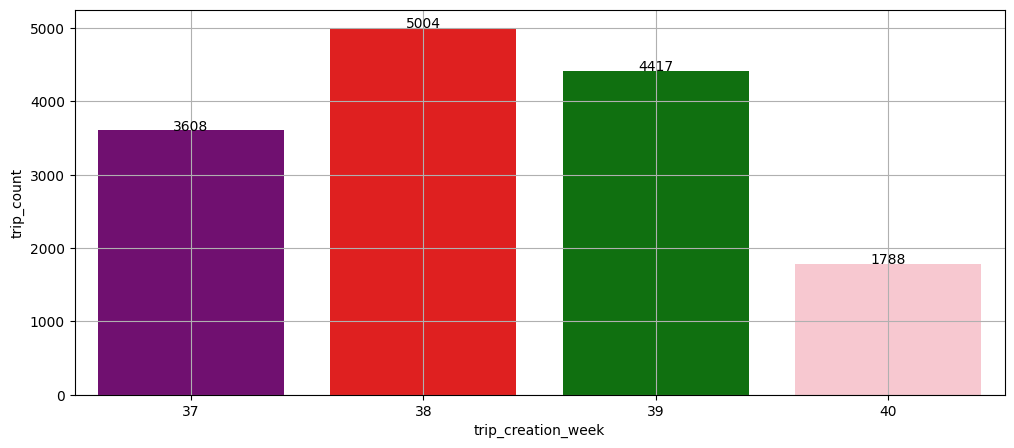

In [ ]:
plt.figure(figsize = (12,5))
#sns.lineplot(data = df_week, x = df_week['trip_creation_week'],y = df_week['trip_count'],color='purple')
sns.barplot(data=df_week, x=df_week['trip_creation_week'], y=df_week['trip_count'], palette=['purple', 'red', 'green', 'pink'])
addlabels(df_week['trip_creation_week'], df_week['trip_count'])
plt.grid()
plt.show()

* We can infer from the above plot that most of the trips were made in the 38th week

In [ ]:
# How many trips are created in the given two months?
df_month = df1.groupby(by = 'trip_creation_month')['trip_uuid'].count().to_frame().reset_index()
df_month['pct'] = np.round(df_month['trip_uuid'] * 100/ df_month['trip_uuid'].sum(), 2)
df_month.head()

,trip_creation_month,trip_uuid,pct
0,9,13029,87.93
1,10,1788,12.07


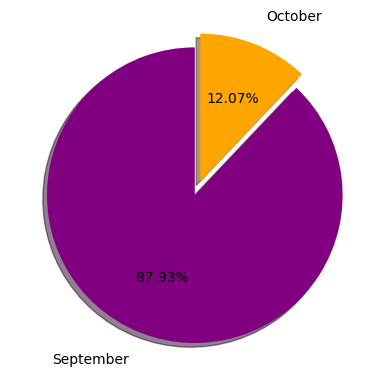

In [ ]:
# Create a subplot for the pie chart
plt.pie(x=df_month['trip_uuid'], colors=['purple', 'orange'], explode=[0, 0.1], autopct='%.2f%%', labels = ['September','October'], shadow=True,labeldistance= 1.2, startangle = 90)
plt.show()

In [ ]:
# How many top 10 number of trips made from different states?
df_state = df1.groupby('source_state')['trip_uuid'].count().to_frame().reset_index()
df_state.rename(columns={'trip_uuid':'trip_count'},inplace = True)
df_state = df_state.sort_values(by='trip_count',ascending = False)[:10]
df_state

,source_state,trip_count
17,Maharashtra,2714
14,Karnataka,2143
10,Haryana,1838
24,Tamil Nadu,1039
25,Telangana,781
26,Uttar Pradesh,762
9,Gujarat,750
7,Delhi,728
28,West Bengal,665
22,Punjab,536


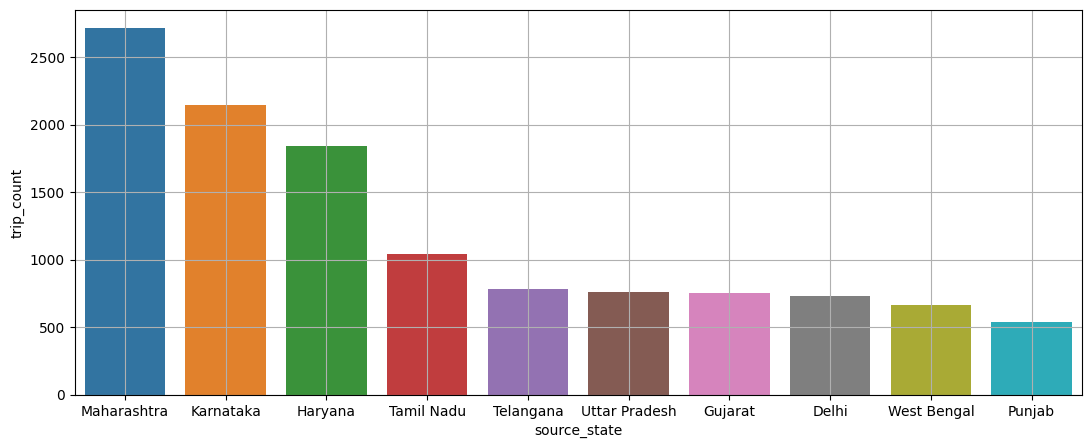

In [ ]:
plt.figure(figsize = (13, 5))
sns.barplot(data = df_state, y = df_state['trip_count'], x = df_state['source_state'])
plt.grid()
plt.show()

**CONCLUSION:**

From the above plot we can observe that maximum trips originated from Maharashtra state followed by Karnataka and Haryana. That means that the seller base is strong in these states.

In [ ]:
# Top 10 number of trips made from different cities?
df_city = df1.groupby('source_city')['trip_uuid'].count().to_frame().reset_index()
df_city.rename(columns={'trip_uuid':'trip_count'},inplace = True)
df_city = df_city.sort_values(by='trip_count',ascending = False)[:10]
df_city

,source_city,trip_count
439,Mumbai,1442
237,Gurgaon,1165
169,Delhi,883
79,Bengaluru,726
100,Bhiwandi,697
58,Bangalore,648
136,Chennai,568
264,Hyderabad,524
516,Pune,480
357,Kolkata,356


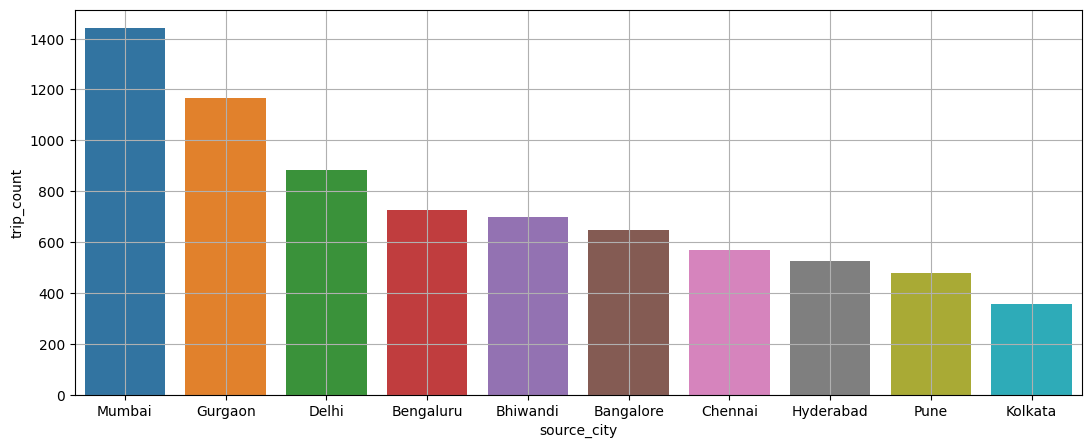

In [ ]:
plt.figure(figsize = (13, 5))
sns.barplot(data = df_city, y = df_city['trip_count'], x = df_city['source_city'])
plt.grid()
plt.show()

**CONCLUSION:**

From the above plot we can observe that maximum trips originated from Mumbai state followed by Gurgoan and Delhi. That means that the seller base is strong in these cities.

In [ ]:
# Top 10 states where number of trips were ended there?
df_des_state = df1.groupby('destination_state')['trip_uuid'].count().to_frame().reset_index()
df_des_state.rename(columns={'trip_uuid':'trip_count'},inplace = True)
df_des_state = df_des_state.sort_values(by='trip_count',ascending = False)[:10]
df_des_state

,destination_state,trip_count
18,Maharashtra,2561
15,Karnataka,2294
11,Haryana,1643
25,Tamil Nadu,1084
28,Uttar Pradesh,811
26,Telangana,784
10,Gujarat,734
30,West Bengal,697
8,Delhi,652
23,Punjab,617


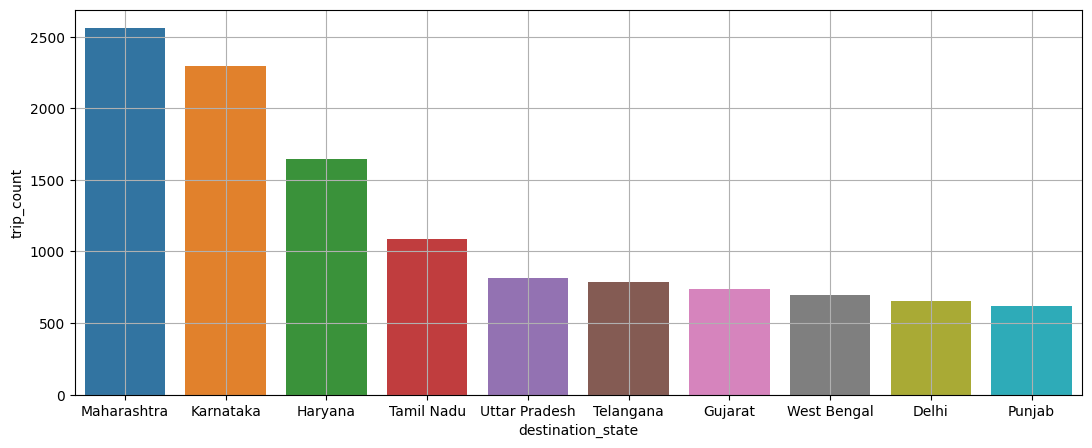

In [ ]:
plt.figure(figsize = (13, 5))
sns.barplot(data = df_des_state, y = df_des_state['trip_count'], x = df_des_state['destination_state'])
plt.grid()
plt.show()

**CONCLUSION:**

From the above plot we can observe that maximum trips ended at Maharashtra state followed by Karnataka and Haryana. That means that the highest demands are strong in these states.

In [ ]:
# Top 10 city where number of trips were ended?
df_des_city = df1.groupby('destination_city')['trip_uuid'].count().to_frame().reset_index()
df_des_city.rename(columns={'trip_uuid':'trip_count'},inplace = True)
df_des_city = df_des_city.sort_values(by='trip_count',ascending = False)[:10]
df_des_city

,destination_city,trip_count
515,Mumbai,1548
96,Bengaluru,975
282,Gurgaon,936
200,Delhi,778
163,Chennai,595
72,Bangalore,551
308,Hyderabad,503
115,Bhiwandi,434
418,Kolkata,384
158,Chandigarh,339


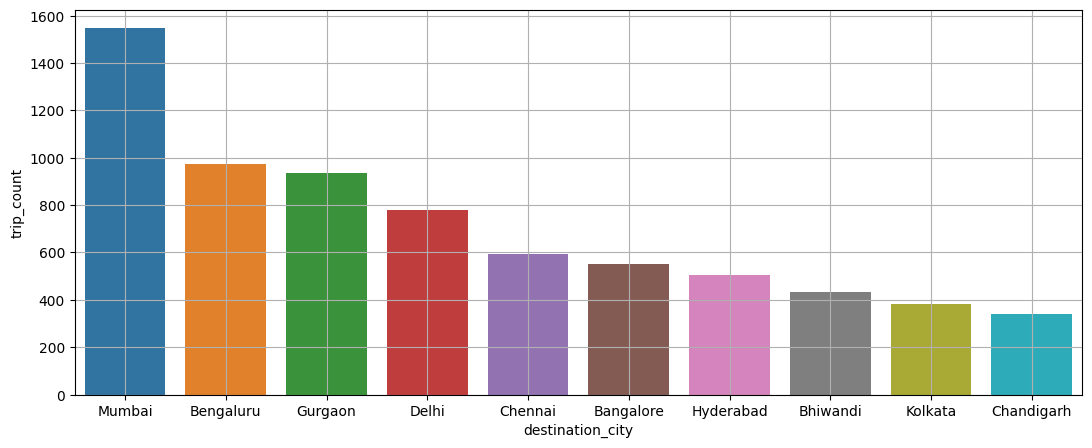

In [ ]:
plt.figure(figsize = (13, 5))
sns.barplot(data = df_des_city, y = df_des_city['trip_count'], x = df_des_city['destination_city'])
plt.grid()
plt.show()

**CONCLUSION:**

From the above plot we can observe that maximum trips ended at Mumbai city followed by Bengaluru and Gurgaon. That means that the demands are strong in these cities.

# **Outlier Detection & Treatment:**

a. Find any existing outliers in numerical features.

b. Visualize the outlier values using Boxplot.

c. Handle the outliers using the IQR method.

In [ ]:
numerical_columns = ['od_total_time', 'start_scan_to_end_scan', 'actual_distance_to_destination','actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
                    'segment_osrm_time', 'segment_osrm_distance']
outliers = df1[numerical_columns].describe().T[['mean','50%']]
outliers['difference'] = outliers['mean'] - outliers['50%']
outliers = outliers[outliers['difference'] > 0]
pd.DataFrame(outliers)

,mean,50%,difference
od_total_time,531.795209,280.765626,251.029583
start_scan_to_end_scan,530.810016,280.000000,250.810016
actual_distance_to_destination,164.477829,48.474072,116.003757
actual_time,357.143768,149.000000,208.143768
osrm_time,161.384018,60.000000,101.384018
osrm_distance,204.344711,65.618805,138.725906
segment_actual_time,353.892273,147.000000,206.892273
segment_osrm_time,180.949783,65.000000,115.949783
segment_osrm_distance,223.201157,70.154404,153.046753


There in the above columns we can see that there are potential outliers presernt in the columns

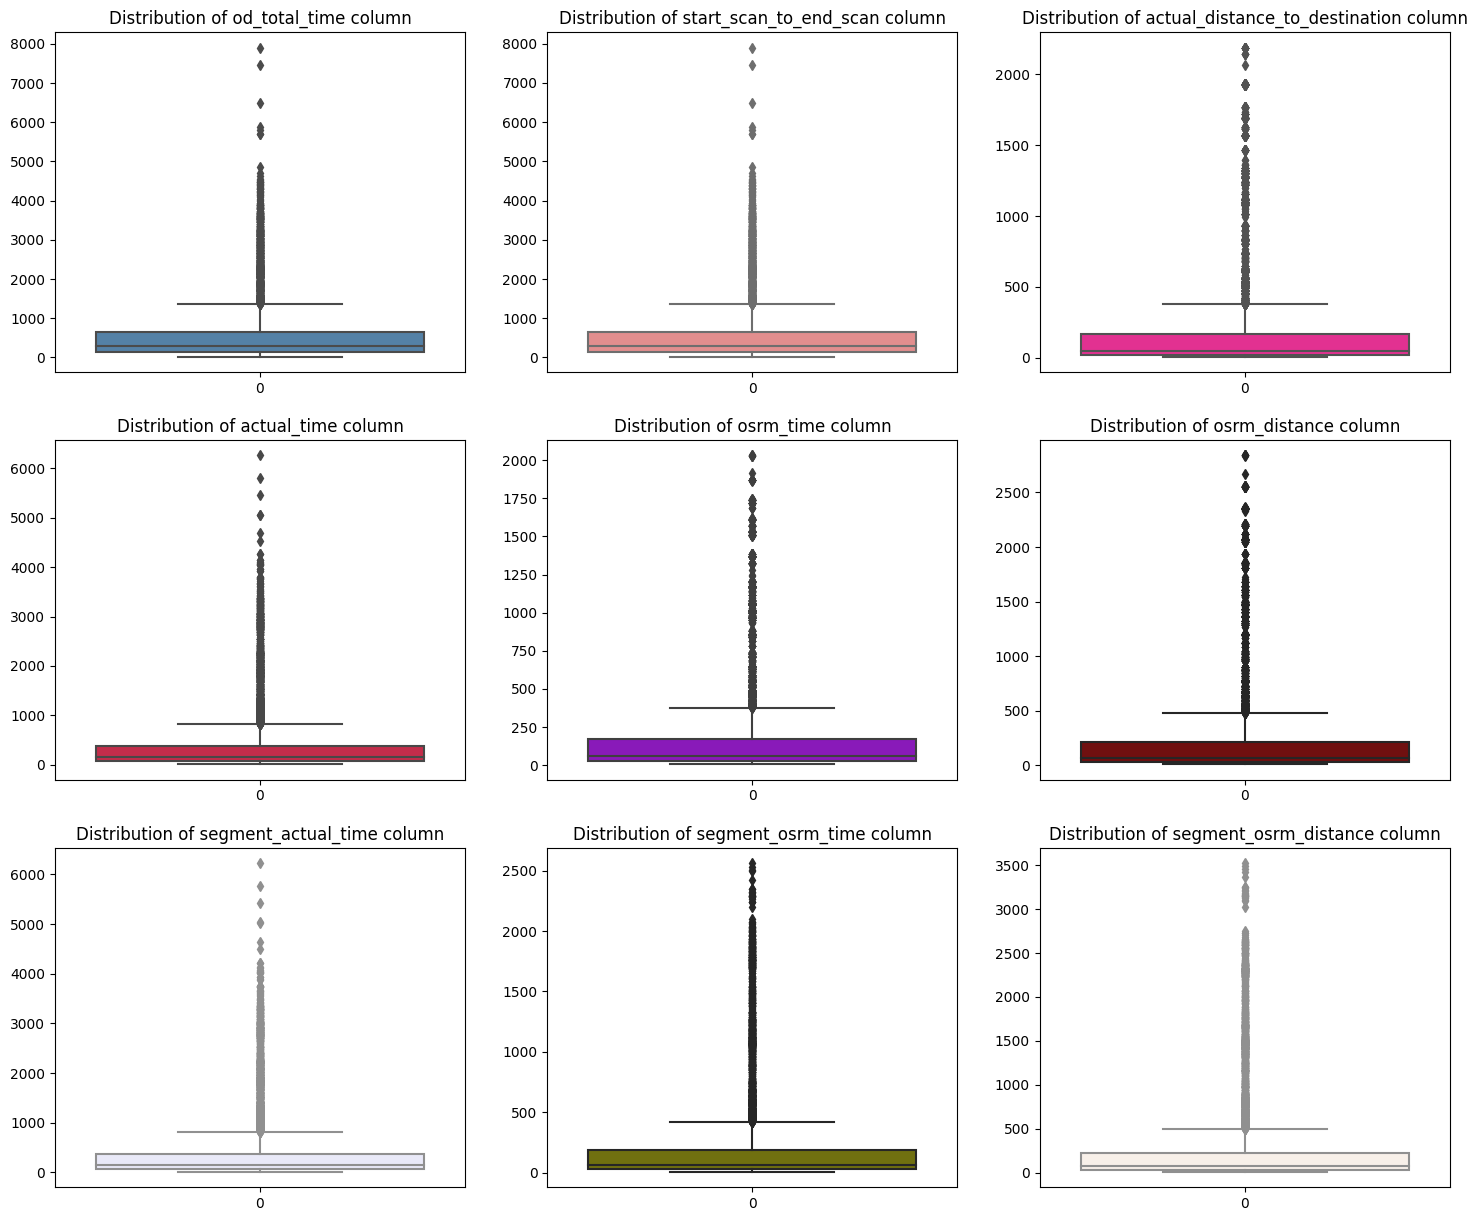

In [ ]:
# Lets visualize it:
plt.figure(figsize = (18, 15))
for i in range(len(numerical_columns)):
    plt.subplot(3, 3, i + 1)
    clr = np.random.choice(list(mpl.colors.cnames))
    sns.boxplot(df1[numerical_columns[i]], color = clr)
    plt.title(f"Distribution of {numerical_columns[i]} column")
    plt.plot()

## **OUTLIER HANDLING USING IQR**

In [ ]:
# calculate q1(25th percentile) and q3 (75th percentile)
Q1 = df1[numerical_columns].quantile(0.25)
Q3 = df1[numerical_columns].quantile(0.75)
# IQR is our Inter quartile Range
IQR = Q3 - Q1

# Filtering out the outliers by keeping only the values that are within 1.5*IQR of Q1 and Q3
df1_no_outliers = df1[~((df1[numerical_columns] < (Q1 - 1.5 * IQR)) | (df1[numerical_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Comparing the shape of the original and outlier-removed dataframes
original_shape = df1.shape
outlier_removed_shape = df1_no_outliers.shape

original_shape, outlier_removed_shape

((14817, 28), (12759, 28))

In [ ]:
# Lets calculate number of outlier present in each features:
for i in numerical_columns:
  q1 = np.quantile(df1[i],0.25)
  q3 = np.quantile(df1[i],0.75)
  IQR = q3 - q1
  lower_bracket = q1 - 1.5 * IQR
  upper_bracket = q3 -  1.5 * IQR
  cal_outlier = df1.loc[(df1[i]<lower_bracket) | df1[i]>upper_bracket]
  print('COLUMN:', i)
  print(f'Q1 : {q1}')
  print(f'Q3 : {q3}')
  print(f'IQR : {IQR}')
  print(f'LOWER BRACKET : {lower_bracket}')
  print(f'UPPER BRACKET : {upper_bracket}')
  print(f'NUMBER OF OUTLIERS : {cal_outlier.shape[0]}')
  print('--'*20)

COLUMN: od_total_time
Q1 : 149.93059088333334
Q3 : 638.1990710833333
IQR : 488.2684801999999
LOWER BRACKET : -582.4721294166665
UPPER BRACKET : -94.20364921666658
NUMBER OF OUTLIERS : 14817
----------------------------------------
COLUMN: start_scan_to_end_scan
Q1 : 149.0
Q3 : 637.0
IQR : 488.0
LOWER BRACKET : -583.0
UPPER BRACKET : -95.0
NUMBER OF OUTLIERS : 14817
----------------------------------------
COLUMN: actual_distance_to_destination
Q1 : 22.837238311767578
Q3 : 164.5832061767578
IQR : 141.74596786499023
LOWER BRACKET : -189.78171348571777
UPPER BRACKET : -48.03574562072754
NUMBER OF OUTLIERS : 14817
----------------------------------------
COLUMN: actual_time
Q1 : 67.0
Q3 : 370.0
IQR : 303.0
LOWER BRACKET : -387.5
UPPER BRACKET : -84.5
NUMBER OF OUTLIERS : 14817
----------------------------------------
COLUMN: osrm_time
Q1 : 29.0
Q3 : 168.0
IQR : 139.0
LOWER BRACKET : -179.5
UPPER BRACKET : -40.5
NUMBER OF OUTLIERS : 14817
----------------------------------------
COLUMN: osr

# **PAIR PLOT:**

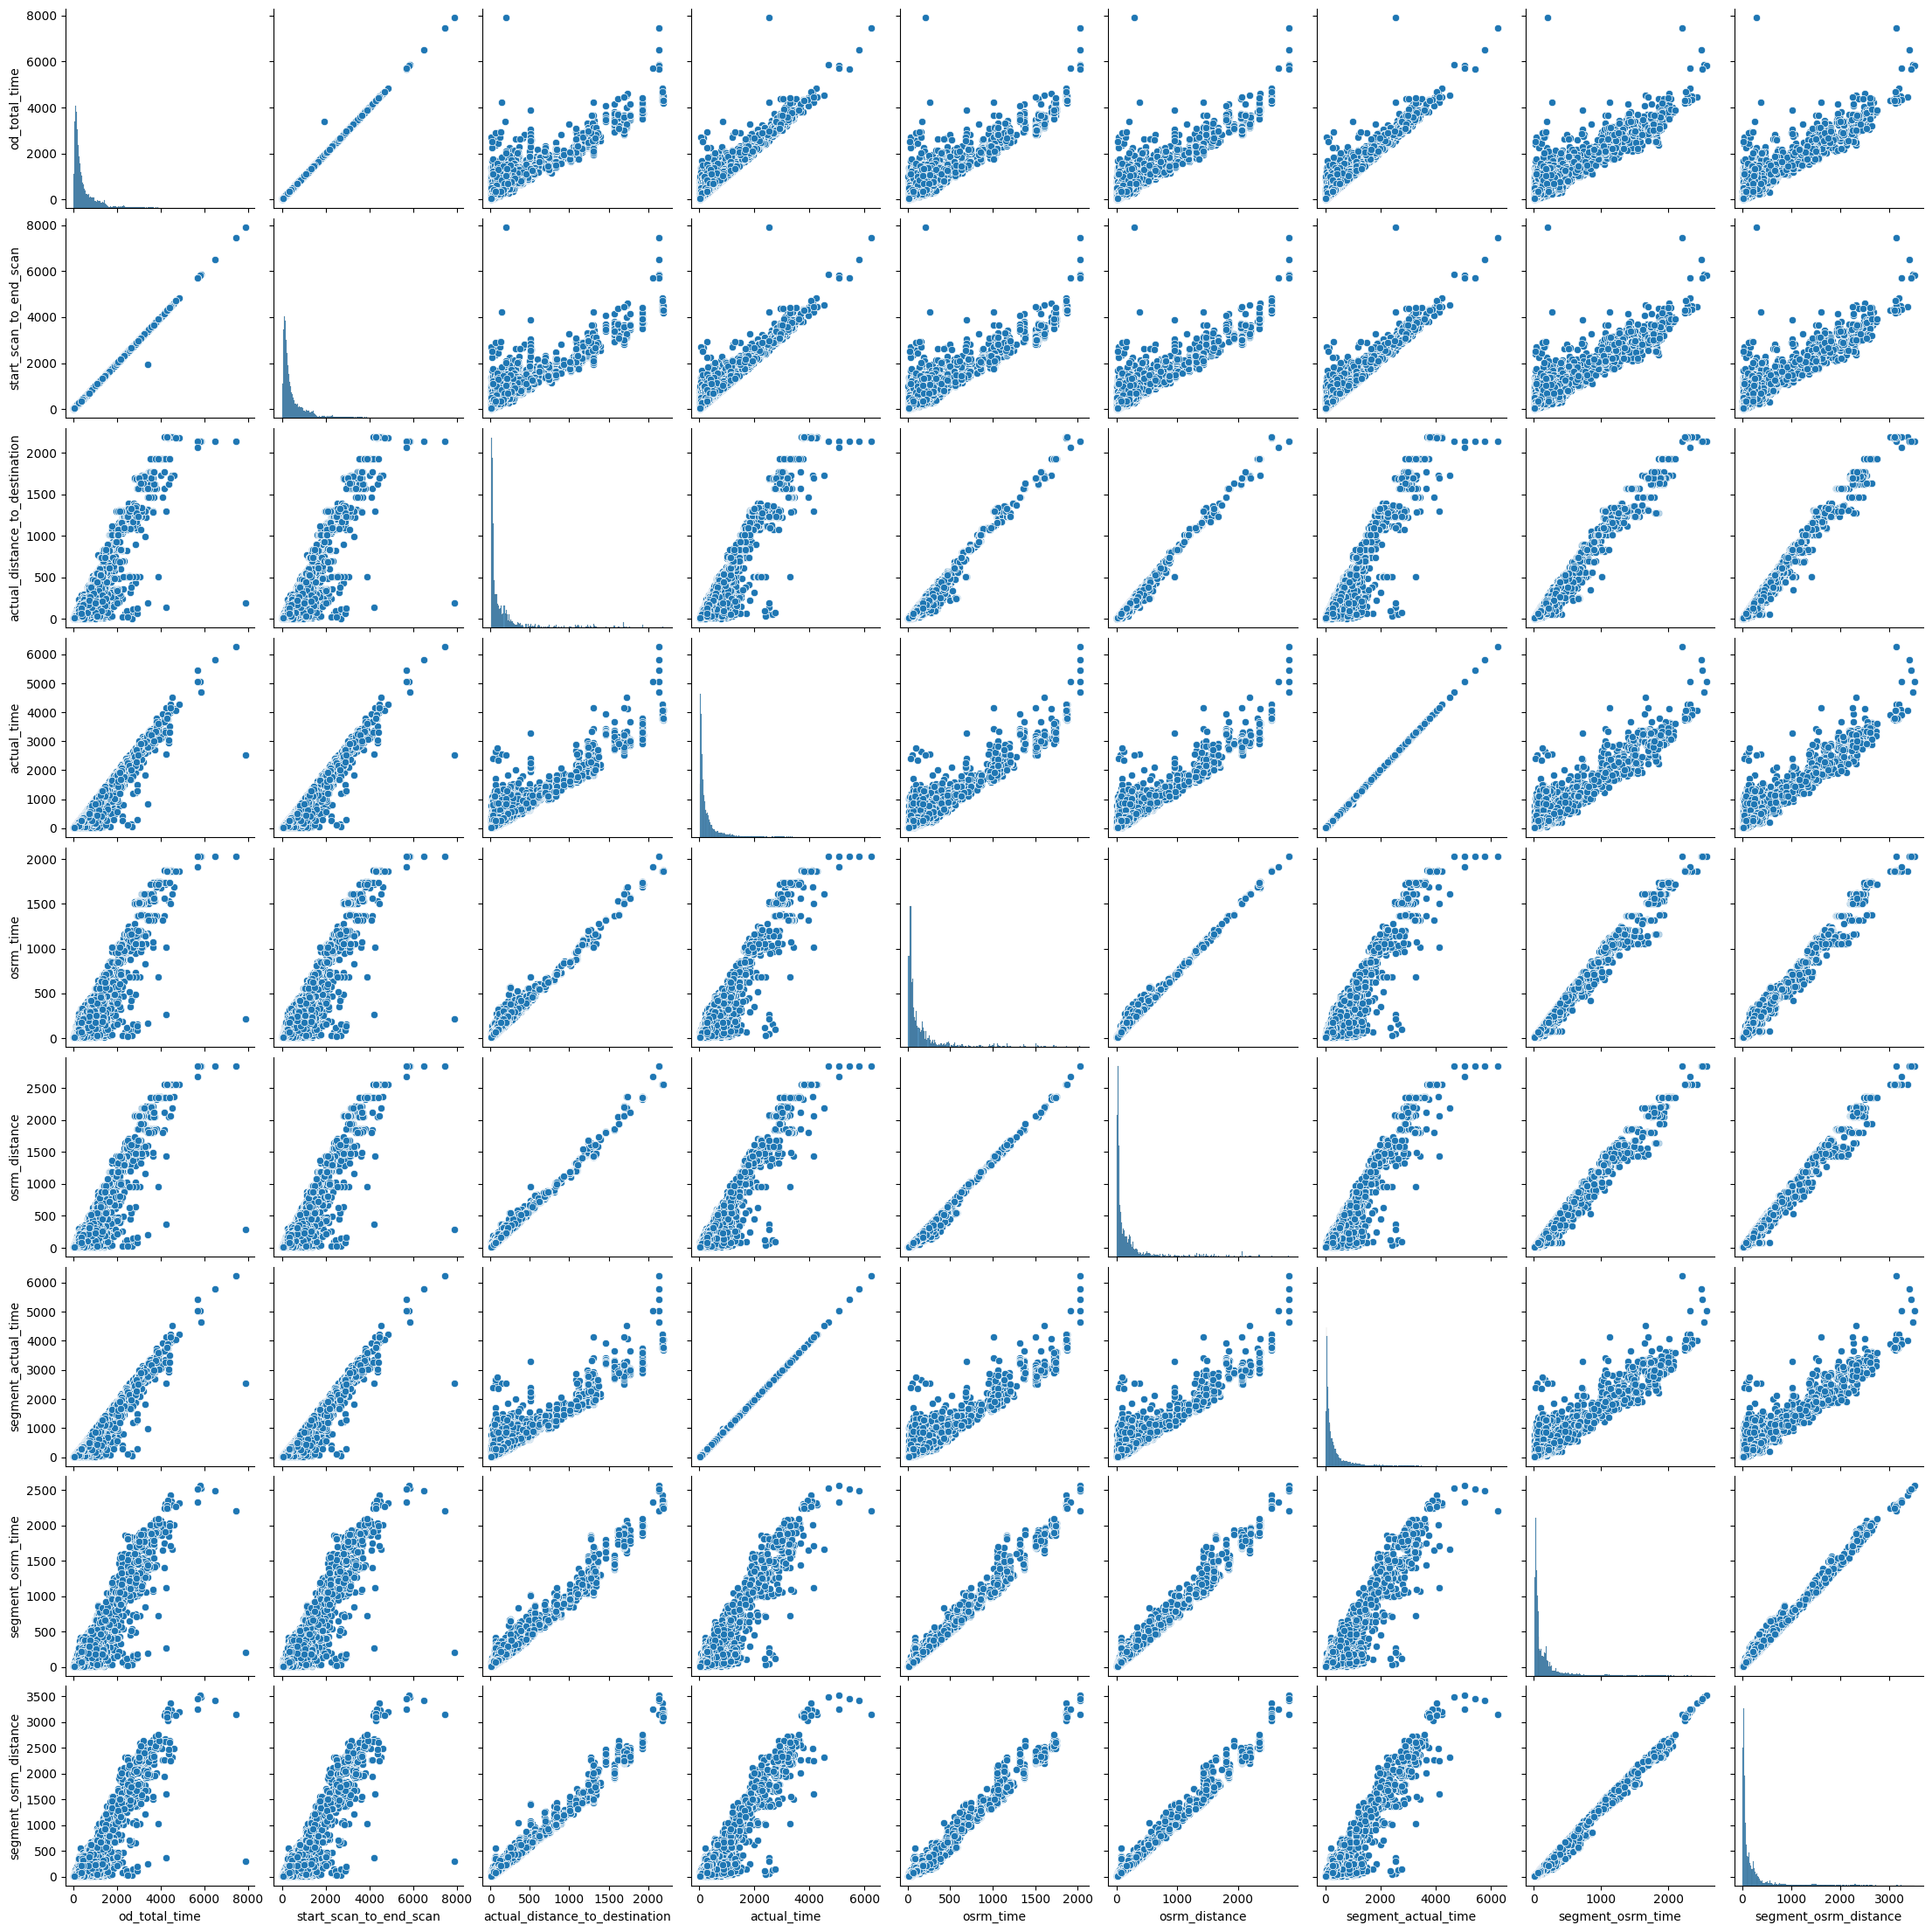

In [ ]:
sns.pairplot(df1[numerical_columns])
plt.show()

# **HEAT MAP:**

In [ ]:
df1_corr = df1[numerical_columns].corr()

[]

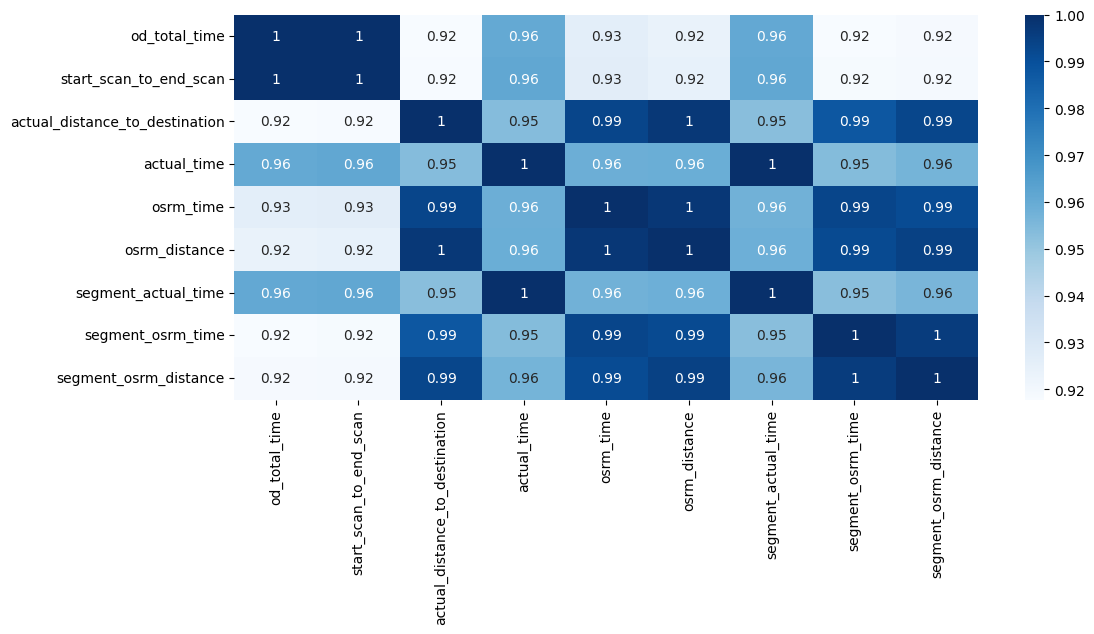

In [ ]:
plt.figure(figsize = (12, 5))
sns.heatmap(data = df1_corr, annot = True,cmap ='Blues')
plt.plot()

Data are very highly correlated i.e. > 0.99 between columns actual_distance_to_destination and orsm_time, segment_orsm_time and segment_orsm_distance.

# Perform one-hot encoding on categorical features

**one-hot encodiing for data:**

In [ ]:
# import library:
from sklearn.preprocessing import LabelEncoder


In [ ]:
# Original column:
df1['data'].value_counts()

training    10654
test         4163
Name: data, dtype: int64

In [ ]:
laber_encoder = LabelEncoder()
df1['data'] = label_encoder.fit_transform(df1['data'])

In [ ]:
df1['data'].value_counts()

1    10654
0     4163
Name: data, dtype: int64

**one-hot encodiing for route type:**

In [ ]:
# Original column:
df1['route_type'].value_counts()

Carting    8908
FTL        5909
Name: route_type, dtype: int64

In [ ]:
# Perform one-hot encoding on categorical column route type:
df1['route_type'] = label_encoder.fit_transform(df1['route_type'])

In [ ]:
df1['route_type'].value_counts()

0    8908
1    5909
Name: route_type, dtype: int64

#**Normalize/ Standardize the numerical features using MinMaxScaler or StandardScaler**

In [ ]:
# Import library for normalization and standardization:(minmaxscaler and standardscaler)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

**Standardization:**

In [ ]:
numerical_columns

['od_total_time',
 'start_scan_to_end_scan',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance']

In [ ]:
standard_data = StandardScaler().fit_transform(df1[numerical_columns])
df_standard_data =pd.DataFrame(standard_data,columns = numerical_columns)
df_standard_data.head()

,od_total_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,2.621986,2.623702,2.162092,2.146251,2.047585,2.124848,2.146791,2.629468,2.633784
1,-0.531255,-0.532593,-0.298944,-0.381461,-0.344144,-0.321920,-0.382742,-0.368643,-0.333670
2,5.161957,5.165134,5.772935,5.325931,5.817598,5.804050,5.310954,5.595785,5.573660
3,-0.654316,-0.654047,-0.482362,-0.531093,-0.539462,-0.498578,-0.530163,-0.524430,-0.488040
4,0.283017,0.282670,-0.121257,-0.028757,-0.163566,-0.155387,-0.024976,-0.209676,-0.183405


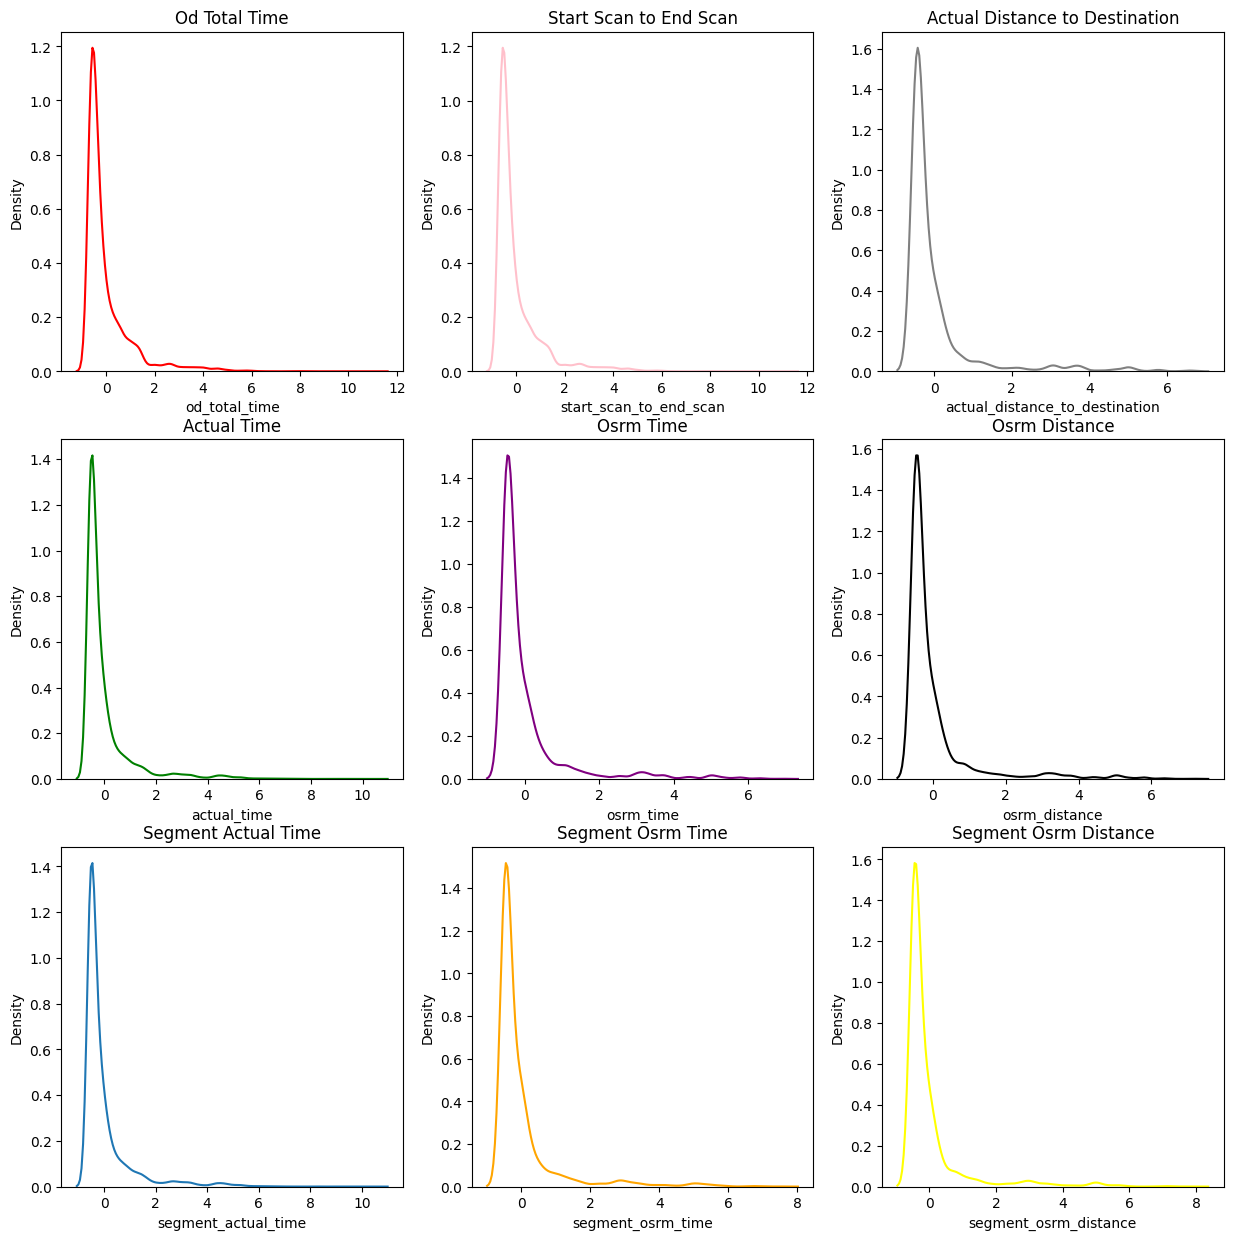

In [ ]:
plt.figure(figsize = (15, 15))
plt.subplot(3,3,1)
sns.kdeplot(df_standard_data['od_total_time'],color = 'red')
plt.title('Od Total Time')

plt.subplot(3,3,2)
sns.kdeplot(df_standard_data['start_scan_to_end_scan'],color = 'pink')
plt.title('Start Scan to End Scan')

plt.subplot(3,3,3)
sns.kdeplot(df_standard_data['actual_distance_to_destination'],color = 'grey')
plt.title('Actual Distance to Destination')

plt.subplot(3,3,4)
sns.kdeplot(df_standard_data['actual_time'],color = 'green')
plt.title('Actual Time')

plt.subplot(3,3,5)
sns.kdeplot(df_standard_data['osrm_time'],color = 'purple')
plt.title('Osrm Time')

plt.subplot(3,3,6)
sns.kdeplot(df_standard_data['osrm_distance'],color = 'black')
plt.title('Osrm Distance')

plt.subplot(3,3,7)
sns.kdeplot(df_standard_data['segment_actual_time'])
plt.title('Segment Actual Time')

plt.subplot(3,3,8)
sns.kdeplot(df_standard_data['segment_osrm_time'],color = 'orange')
plt.title('Segment Osrm Time')

plt.subplot(3,3,9)
sns.kdeplot(df_standard_data['segment_osrm_distance'],color = 'yellow')
plt.title('Segment Osrm Distance')

plt.show()

**Normalizatioin:**

In [ ]:
normalize_data = MinMaxScaler().fit_transform(df1[numerical_columns])
df_normalized = pd.DataFrame(normalize_data,columns = numerical_columns)
df_normalized.head()

,od_total_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,0.284016,0.283937,0.374613,0.248242,0.350938,0.346972,0.247388,0.391712,0.373134
1,0.020082,0.019937,0.029476,0.021419,0.030602,0.026859,0.021218,0.023065,0.021373
2,0.496617,0.496508,0.880999,0.533568,0.855874,0.828325,0.530301,0.756450,0.721625
3,0.009782,0.009778,0.003753,0.007992,0.004442,0.003747,0.008037,0.003909,0.003074
4,0.088239,0.088127,0.054395,0.053069,0.054788,0.048647,0.053207,0.042611,0.039185


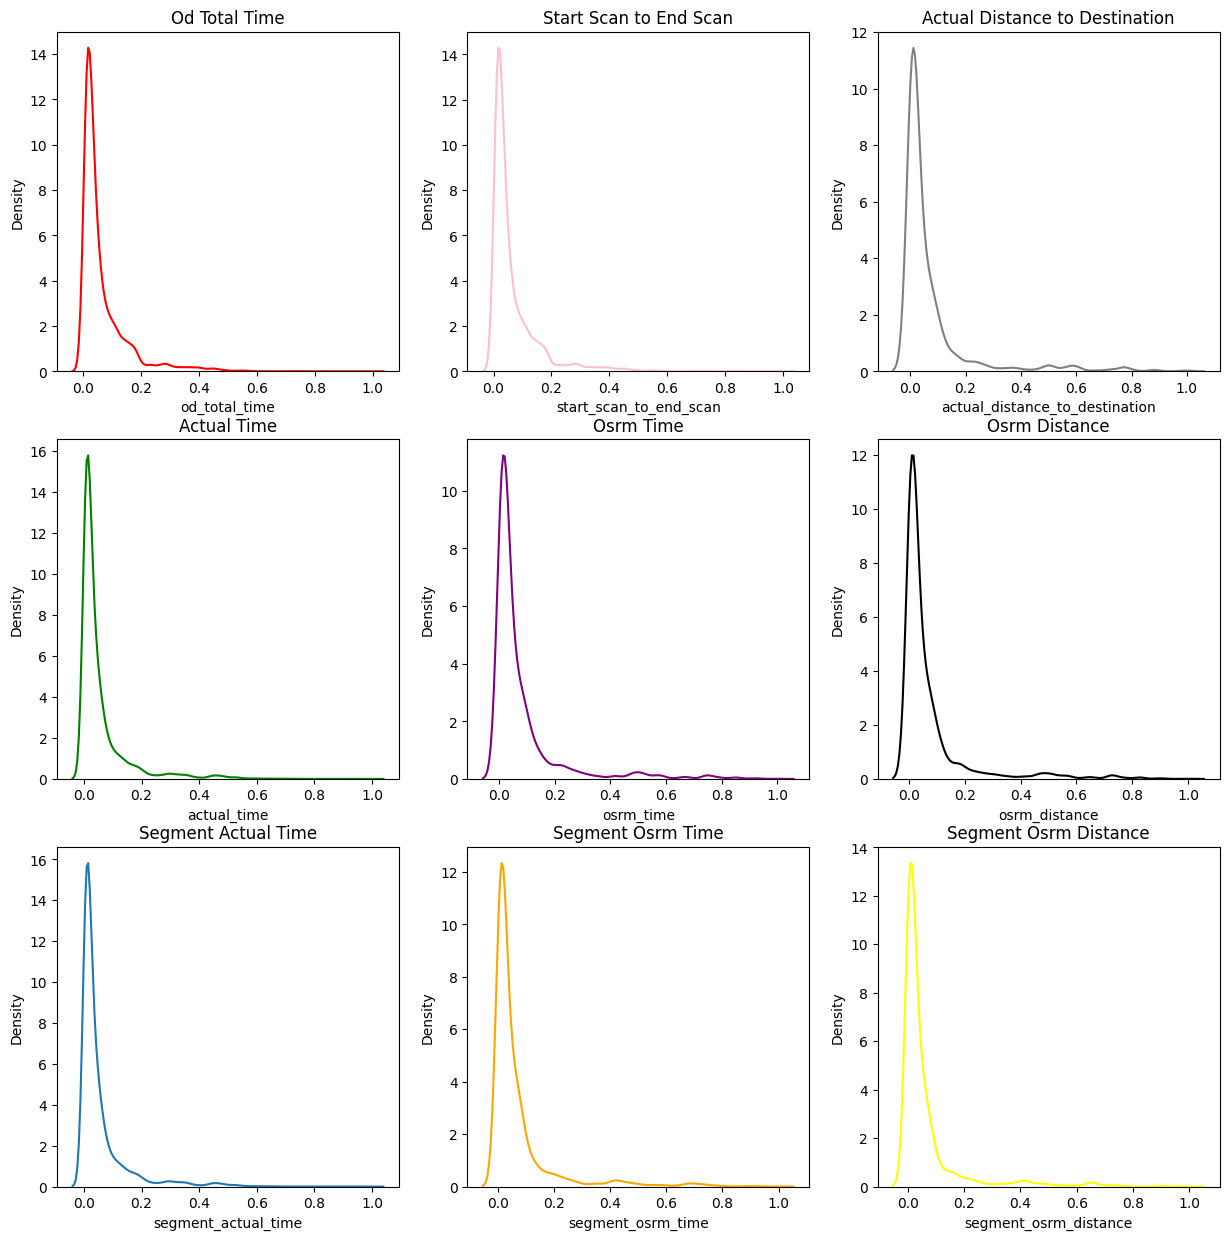

In [ ]:
plt.figure(figsize = (15, 15))
plt.subplot(3,3,1)
sns.kdeplot(df_normalized['od_total_time'],color = 'red')
plt.title('Od Total Time')

plt.subplot(3,3,2)
sns.kdeplot(df_normalized['start_scan_to_end_scan'],color = 'pink')
plt.title('Start Scan to End Scan')

plt.subplot(3,3,3)
sns.kdeplot(df_normalized['actual_distance_to_destination'],color = 'grey')
plt.title('Actual Distance to Destination')

plt.subplot(3,3,4)
sns.kdeplot(df_normalized['actual_time'],color = 'green')
plt.title('Actual Time')

plt.subplot(3,3,5)
sns.kdeplot(df_normalized['osrm_time'],color = 'purple')
plt.title('Osrm Time')

plt.subplot(3,3,6)
sns.kdeplot(df_normalized['osrm_distance'],color = 'black')
plt.title('Osrm Distance')

plt.subplot(3,3,7)
sns.kdeplot(df_normalized['segment_actual_time'])
plt.title('Segment Actual Time')

plt.subplot(3,3,8)
sns.kdeplot(df_normalized['segment_osrm_time'],color = 'orange')
plt.title('Segment Osrm Time')

plt.subplot(3,3,9)
sns.kdeplot(df_normalized['segment_osrm_distance'],color = 'yellow')
plt.title('Segment Osrm Distance')

plt.show()

By Normalizing out features we can observe that all our data is between the range of 0 to 1.

# **Hypothesis Testing:**

**Perform hypothesis testing / visual analysis between :**
Lets formulate everything:

*STEP-1* : Set up Null Hypothesis

Null Hypothesis ( H0 ) - od_total_time (Total Trip Time) and start_scan_to_end_scan (Expected total trip time) are same.

Alternate Hypothesis ( HA ) - od_total_time (Total Trip Time) and start_scan_to_end_scan (Expected total trip time) are different.

*STEP-2* : Checking for basic assumpitons for the hypothesis

Distribution check using QQ Plot
Homogeneity of Variances using Lavene's test

*STEP-3*: Define Test statistics; Distribution of T under H0.

If the assumptions of T Test are met then we can proceed performing T Test for independent samples else we will perform the non parametric test equivalent to T Test for independent sample i.e., Mann-Whitney U rank test for two independent samples.

*STEP-4*:
Compute the p-value and fix value of alpha.

(We set our *alpha to be 0.05*)

*STEP-5*: Compare p-value and alpha.

Based on p-value, we will accept or reject H0.

p-val > alpha : Accept H0
p-val < alpha : Reject H0


In [ ]:
# Import all the necessary library:
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import kruskal, shapiro, levene, boxcox,kruskal

a. Actual_time aggregated value and OSRM time aggregated value.

In [ ]:
df1[['actual_time','osrm_time']].describe()

,actual_time,osrm_time
count,14817.000000,14817.000000
mean,357.143768,161.384018
std,561.396118,271.360992
min,9.000000,6.000000
25%,67.000000,29.000000
50%,149.000000,60.000000
75%,370.000000,168.000000
max,6265.000000,2032.000000


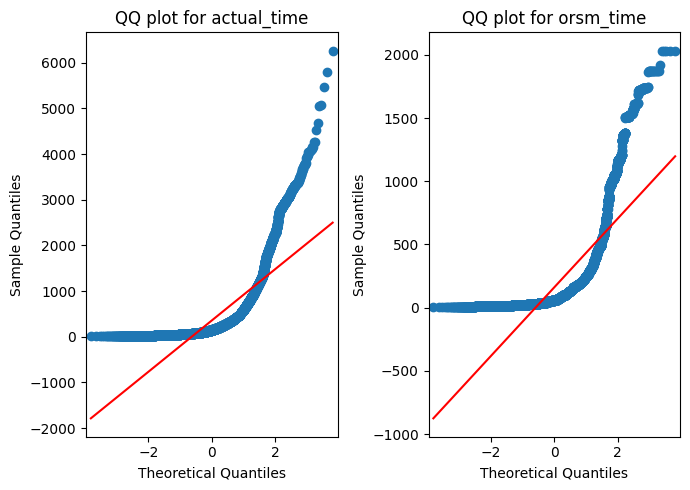

In [ ]:
# Visual test do check for normality of the data:
fig, axes = plt.subplots(1, 2, figsize=(7, 5))

# Plot for actual_time
axes[0].set_title('QQ plot for actual_time')
qqplot(df1['actual_time'], line='s', ax=axes[0])

# Plot for segment_actual_time
axes[1].set_title('QQ plot for orsm_time')
qqplot(df1['osrm_time'], line='s', ax=axes[1])

plt.tight_layout()
plt.show()

Conclusion:
It can be seen from the above that the sample do not follow noraml distribution

**Shapiro test:**


In [ ]:
#H0: The sample data follows normal distribution
#H0: The sample data does not follow normal distribution
test_stat, p_value = shapiro(df1['actual_time'].sample(5000))
print('p_value',p_value)
if p_value < 0.5:
  print('The data does not follow normal distribution')
else:
  print('The data does follows the Normal distribution')

p_value 0.0
The data does not follow normal distribution


In [ ]:
test_stat, p_value = shapiro(df1['osrm_time'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


Therefore data does not follows the Normal Distribution , so we perform boccox transformation.

In [ ]:
transformed_actual_time = boxcox(df1['actual_time'])[0]
test_stat, p_value = spy.shapiro(transformed_actual_time)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 1.020620453603145e-28
The sample does not follow normal distribution


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
transformed_actual_time = boxcox(df1['osrm_time'])[0]
test_stat, p_value = shapiro(transformed_actual_time)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 3.5882550510138333e-35
The sample does not follow normal distribution


* Even after applying the boxcox transformation on each of the "actual_time" and "osrm_time" columns, the distributions do not follow normal distribution.

**Levene test** for checking the variances between the 2 groups

In [ ]:
# H0 ; Data have equal Variance
# HA : Data do not have equal Variance

test_stat, p_value = levene(df1['actual_time'], df1['osrm_time'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples do not have  Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 1.871098057987424e-220
The samples do not have  Homogenous Variance


* Since the samples do not follow any of the assumptions T-Test cannot be applied here, we can perform its non parametric equivalent test i.e., Kruskal test for two independent samples.

In [ ]:
#Null Hypothesis (H0): There is no significant difference among the medians of the groups.
# Alternative Hypothesis (Ha): At least one group has a different median than the others.
test_stat, p_value = kruskal(df1['actual_time'], df1['osrm_time'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples are not similar')
else:
    print('The samples are similar ')

p-value 0.0
The samples are not similar


* Therefore final conclusion is that the actual time and osrm time are not similar.

b.Actual_time aggregated value and segment actual time aggregated
value.

In [ ]:
df1[['actual_time', 'segment_actual_time']].describe()

,actual_time,segment_actual_time
count,14817.000000,14817.000000
mean,357.143768,353.892273
std,561.396118,556.247925
min,9.000000,9.000000
25%,67.000000,66.000000
50%,149.000000,147.000000
75%,370.000000,367.000000
max,6265.000000,6230.000000


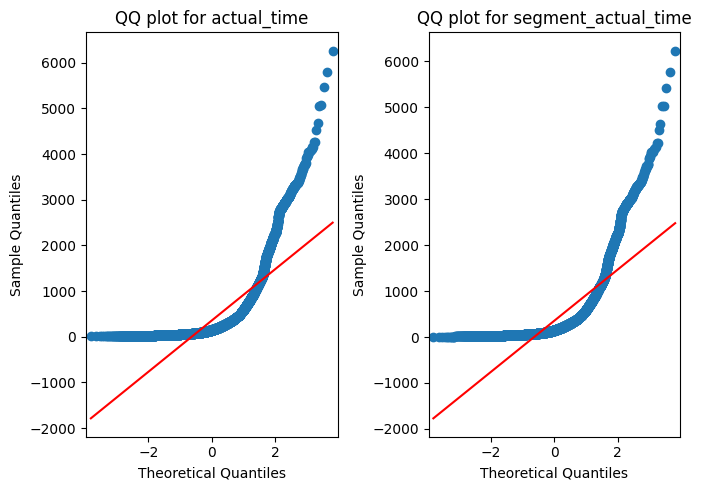

In [ ]:
# check for the nomality visualize:
fig, axes = plt.subplots(1, 2, figsize=(7, 5))

# Plot for actual_time
axes[0].set_title('QQ plot for actual_time')
qqplot(df1['actual_time'], line='s', ax=axes[0])

# Plot for segment_actual_time
axes[1].set_title('QQ plot for segment_actual_time')
qqplot(df1['segment_actual_time'], line='s', ax=axes[1])

plt.tight_layout()
plt.show()

It can be seen from the above plots that the samples do not come from normal distribution.

In [ ]:
# Check wiith shapiro test:
alpha = 0.05
# H0 : The sample follows normal distribution or gaussian
# Ha : The sample does not follow normal distribution
test_stat, p_value = shapiro(df1['actual_time'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


In [ ]:
test_stat, p_value = shapiro(df1['segment_actual_time'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


In [ ]:
# Transform data using boxcox transformation to check if transform data follows normal distribution or not.
transformed_actual_time = boxcox(df1['actual_time'])[0]
test_stat,p_value = shapiro(transformed_actual_time)
print('p-value:', p_value)
if p_value< 0.05:
  print('Sample does not follow normal distribution')
else:
  print('Sample follows normal distribution')

p-value: 1.020620453603145e-28
Sample does not follow normal distribution


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
transformed_seg_actual_time = boxcox(df1['segment_actual_time'])[0]
test_stat,p_value = shapiro(transformed_seg_actual_time)
print('p-value:', p_value)
if p_value< 0.05:
  print('Sample does not follow normal distribution')
else:
  print('Sample follows normal distribution')

p-value: 5.700074948787037e-29
Sample does not follow normal distribution


CONCLUSION:
Even after applying the boxcox transformation on each of the features the disritbution does follows normal distribution.

In [ ]:
# Lavene's test checks the Homogeneity of Variances;
# H0: Varainces is equal between the groups
# Ha: Varainces is not equal between the groups

test_stat, p_value = levene(df1['actual_time'], df1['segment_actual_time'])
print('p-value', p_value)
if p_value <0.05:
  print('The samples does not have homogenous variances')
else:
  print('The samples have Homogenous Variance')

p-value 0.695502241317651
The samples have Homogenous Variance


Since the samples are not from normal distribution T-Test cannot be applied here, we can perform its non parametric equivalent test i.e., kruskal test for two independent samples.

**Kruska test**(as all our assumption gets rejected)

In [ ]:
# Null hypothesis (H0): The medians of all groups are equal.
# Alternative hypothesis (H1): At least one group's median is different from the others.
test_stat, p_value = kruskal(df1['actual_time'], df1['segment_actual_time'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples are not similar')
else:
    print('The samples are similar ')

p-value 0.4164231265256002
The samples are similar 


 Therefore from the KRUSKAL test we can conclude that samples are similar

c. OSRM distance aggregated value and segment OSRM distance
aggregated value.

In [ ]:
df1[['osrm_distance', 'segment_osrm_distance']]

,osrm_distance,segment_osrm_distance
0,991.352295,1320.473267
1,85.111000,84.189400
2,2354.066650,2545.267822
3,19.680000,19.876600
4,146.791794,146.791901
...,...,...
14812,73.462997,64.855103
14813,16.088200,16.088299
14814,58.903702,104.886597
14815,171.110306,223.532394


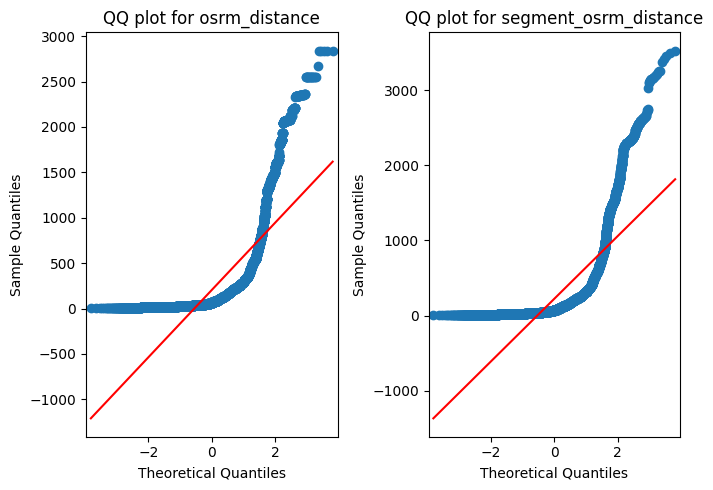

In [ ]:
# Visual lets check if data follows normal distribution or not
# check for the nomality visualize:
fig, axes = plt.subplots(1, 2, figsize=(7, 5))

# Plot for actual_time
axes[0].set_title('QQ plot for osrm_distance')
qqplot(df1['osrm_distance'], line='s', ax=axes[0])

# Plot for segment_actual_time
axes[1].set_title('QQ plot for segment_osrm_distance')
qqplot(df1['segment_osrm_distance'], line='s', ax=axes[1])

plt.tight_layout()
plt.show()

* It can be seen from the above plots that the samples do not come from normal distribution.

Shapiro-Wilk test for normality

In [ ]:
# H0 : The sample follows normal distribution
# Ha : The sample does not follow normal distribution
alpha = 0.05
# Test Statistics : Shapiro-Wilk test for normality
test_stat, p_value = shapiro(df1['osrm_distance'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


In [ ]:
test_stat, p_value = shapiro(df1['segment_osrm_distance'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


* Data does not follows Normal distribution

Lets perform Boxcox transformation to the normality of data:

In [ ]:
transformed_osrm_distance = boxcox(df1['osrm_distance'])[0]
test_stat, p_value = spy.shapiro(transformed_osrm_distance)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 7.063104779582808e-41
The sample does not follow normal distribution


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
transformed_segment_osrm_distance = boxcox(df1['segment_osrm_distance'])[0]
test_stat, p_value = spy.shapiro(transformed_segment_osrm_distance)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 3.049169406432229e-38
The sample does not follow normal distribution


* Even after applying the boxcox transformation on each of the "osrm_distance" and "segment_osrm_distance" columns, the distributions do not follow normal distribution.

* Homogeneity of Variances using **Lavene's test**

In [ ]:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance

test_stat, p_value = levene(df1['osrm_distance'], df1['segment_osrm_distance'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples do not have Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 0.00020976006524780905
The samples do not have Homogenous Variance


* Since the samples do not follow any of the assumptions, T-Test cannot be applied here. We can perform its non parametric equivalent test i.e., Kruskal test for two independent samples.

In [ ]:
# Null hypothesis (H0): The medians of all groups are equal.
# Alternative hypothesis (H1): At least one group's median is different from the others.
test_stat, p_value = kruskal(df1['osrm_distance'], df1['segment_osrm_distance'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples are not similar')
else:
    print('The samples are similar ')

p-value 9.509377942769529e-07
The samples are not similar


*  Therfore it can be concluded that osrm_distance and segment_osrm_distance are not similar.

d. OSRM time aggregated value and segment OSRM time aggregated
value.

In [ ]:
df1[['osrm_time', 'segment_osrm_time']].describe()

,osrm_time,segment_osrm_time
count,14817.000000,14817.000000
mean,161.384018,180.949783
std,271.360992,314.542053
min,6.000000,6.000000
25%,29.000000,31.000000
50%,60.000000,65.000000
75%,168.000000,185.000000
max,2032.000000,2564.000000


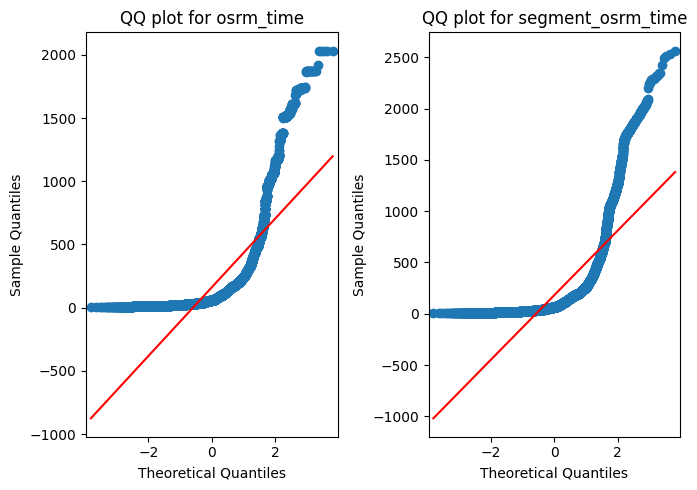

In [ ]:
# Visual lets check if data follows normal distribution or not
# check for the nomality visualize:
fig, axes = plt.subplots(1, 2, figsize=(7, 5))

# Plot for actual_time
axes[0].set_title('QQ plot for osrm_time')
qqplot(df1['osrm_time'], line='s', ax=axes[0])

# Plot for segment_actual_time
axes[1].set_title('QQ plot for segment_osrm_time')
qqplot(df1['segment_osrm_time'], line='s', ax=axes[1])

plt.tight_layout()
plt.show()

* From the above figure we can infer that the samples are not normally distributed

In [ ]:
# lets see if data is normally distributed or not using Shapiro test
# H0: The sample follows Normal distribution
# Ha : The sample doesn't follow normal distribution
# Test Statistics : shapiro wilk test for normality
alpha = 0.05
test_stat, p_value = shapiro(df1['osrm_time'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


In [ ]:
test_stat, p_value = shapiro(df1['segment_osrm_time'].sample(5000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 0.0
The sample does not follow normal distribution


* Final conclusion is data are not normally distributed

In [ ]:
# Data Transformation using Boxcox transformation to check data follows normal distribution
transformed_osrm_time = boxcox(df1['osrm_time'])[0]
test_stat, p_value = spy.shapiro(transformed_osrm_time)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 3.5882550510138333e-35
The sample does not follow normal distribution


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
transformed_segment_osrm_time = boxcox(df1['segment_osrm_time'])[0]
test_stat, p_value = spy.shapiro(transformed_segment_osrm_time)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 4.943039152219146e-34
The sample does not follow normal distribution


* Conclusion even after performing boxcox transformation on each features osrm_time and segment_osrm_time , The distribution does not follow normal distribution.

**Levene Test** for checking the homogenity of variances between the groups

In [ ]:
# H0 : Homogenous Variance or variance are equal between the 2 groups
# Ha : Non Homogenous Variance

test_stat, p_value = levene(df1['osrm_time'], df1['segment_osrm_time'])
print('p-value', p_value)

if p_value < 0.05:
    print('The samples do not have Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 8.349506135727595e-08
The samples do not have Homogenous Variance


* Since the samples do not follow any of the assumptions, T-Test cannot be applied here. We can perform its non parametric equivalent test kruskal test for two independent samples.

**Kruskal test** (as all our assumtion are rejecte)

In [ ]:
# Null hypothesis (H0): The medians of all groups are equal.
# Alternative hypothesis (H1): At least one group's median is different from the others.
test_stat, p_value = kruskal(df1['osrm_time'], df1['segment_osrm_time'])
print('p-value', p_value)
if p_value < 0.05:
    print('The samples are not similar')
else:
    print('The samples are similar ')

p-value 2.2995280965453158e-08
The samples are not similar


* Therefore we can be concluded that osrm_time and segment_osrm_time are not similar.

# **BUSINESS INSIGHT:**

1. The data is given from the period '2018-09-12 00:00:16' to '2018-10-08 03:00:24'.(September-12-2018, October-08-2018)

2. Most of the data present is of testing rather thenr training(In comparision).

3. Most common route type is Carting(Handling system consisting of small vehicles (carts)) which is of

4. There are about 14817 unique trip IDs, 1508 unique source centers, 1481 unique destination_centers, 690 unique source cities, 806 unique destination cities.

5. The names of 14 unique location ids are missing in the data.

6.  The number of trips start increasing after the noon, becomes maximum at 10 P.M and then start decreasing.

7.  The maximum number of trips is generated during the 38th week.

8. Most orders come mid-month. That means customers usually make more orders in the middle of the month.

9. Most orders are sourced from the states like Maharashtra, Karnataka, Haryana, Tamil Nadu, Telangana

10. Amongst the top 10, Maximum number of trips originated from Mumbai city followed by Gurgaon Delhi, Bengaluru and Bhiwandi. That means that the seller base is strong in these cities.

11. Maximum number of trips ended in Maharashtra state followed by Karnataka, Haryana, Tamil Nadu and Uttar Pradesh. That means that the number of orders placed in these states is significantly high.

12. Maximum number of trips ended in Mumbai city followed by Bengaluru, Gurgaon, Delhi and Chennai. That means that the number of orders placed in these cities is significantly high.

13. Most orders in terms of destination are coming from cities like bengaluru, mumbai, gurgaon, bangalore, Delhi.

14. Features start_scan_to_end_scan and od_total_time(created feature) are statistically similar.

15. Features actual_time & osrm_time are statitically different.

16. The Features like segment_actual_time and start_scan_to_end_scan are statistically similar.

18. Features osrm_distance and segment_osrm_distance are statistically different from each other.

19. There is statistical difference between osrm_time & segment_osrm_times (they are not the same).

# **RECOMMENDATAIONS:**

1. **Improve Communication:** Keep customers informed about expected delivery times, especially during peak periods, to manage expectations and improve satisfaction.

2. **Focus on Peak Times:** Allocate more resources during peak hours (10 PM to
midnight) and the 38th week of the year. Ensure sufficient staffing and transportation availability.
3. **Preparation in advance:** Increase readiness around mid-month, when peak order placement occurs, to handle increased volume effectively.
Geographic Optimization

4. **Strengthen Key Cities and States:** Concentrate resources in the top source and destination cities and states like particularly Maharashtra, Karnataka, Haryana, Tamil Nadu, and Uttar Pradesh.

5. **Route and Trip Efficiency**
Optimize Carting Routes: Since Carting is the most common route type, analyze these routes for efficiency improvements, such as direct routes or better traffic management.
6. **Data Utilization:**
Advanced Analytics for Predictions: Employ predictive analytics to anticipate demand spikes, especially during identified peak times, and adjust operations accordingly.
6. **Technology Utilization:** Improve GPS and Routing Technology. Utilize advanced GPS tracking and routing technologies to find the most efficient routes in real-time, reducing distance and time discrepancies.
7. **Regular Data Review:** Continuously monitor trip data to identify new patterns or changes in existing trends.
8. **Feedback Mechanisms:** Implement feedback loops with drivers and customers to gain insights into ground realities and improve service quality.
9. **Explore New Markets:** Consider expanding into less serviced areas while maintaining the focus on high-demand corridors.
10. **Improvement in Route Types:** Analyze the potential of increasing Full Truck Load (FTL) trips where feasible to improve efficiency for longer or bulk deliveries.
11. **Driver Safety Programs:** Implement safety programs for drivers, especially considering the late-night peak hours, to ensure their well-being and reduce the risk of accidents.
12. **Sustainability Initiatives**
Eco-Friendly Practices; Explore options for more environmentally friendly vehicles or practices, particularly in high-traffic areas, to reduce the carbon footprint.